# Celda 01 - Importaciones

In [ ]:
# Importaciones

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss, acf
from statsmodels.graphics.tsaplots import plot_acf
import os
import random
import pickle
import time
from scipy.stats import gaussian_kde, wilcoxon, norm

from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Dense, Input, LSTM

# Celda 02 — Montar Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Fase 1

### Celda 03 — Definir rutas de archivos

In [ ]:
# RUTAS Y PARÁMETROS

RUTA_BASE    = '/content/drive/MyDrive/Embalses/'
RUTA_DATOS   = RUTA_BASE + 'Datos_base/'
RUTA_FIGURAS = RUTA_BASE + 'Figuras/'

ARCHIVO_VOLUMEN = RUTA_DATOS + 'PD_Embalses.xlsx'
ARCHIVO_PRECIP  = RUTA_DATOS + 'PR_Embalses.xlsx'

FECHA_INICIO = pd.Timestamp('2006-01-01')
FECHA_FIN    = pd.Timestamp('2024-12-31')

os.makedirs(RUTA_FIGURAS, exist_ok=True)

### Celda 04 — Carga de volúmenes

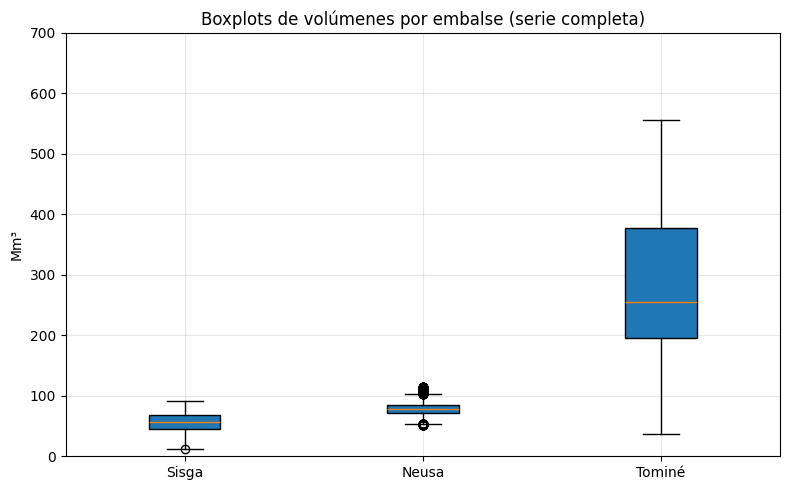

In [ ]:
# CARGA DE VOLÚMENES (PD_Embalses.xlsx)

# Leer las hojas del excel y almacenar en diferentes diccionarios
Datos_Sisga  = pd.read_excel(ARCHIVO_VOLUMEN, ['DT_SISGA'])
Datos_Neusa  = pd.read_excel(ARCHIVO_VOLUMEN, ['DT_NEUSA'])
Datos_Tomine = pd.read_excel(ARCHIVO_VOLUMEN, ['DT_TOMINE'])

# Volver dataframes cada uno de los diccionarios
df_sisga  = Datos_Sisga['DT_SISGA']
df_neusa  = Datos_Neusa['DT_NEUSA']
df_tomine = Datos_Tomine['DT_TOMINE']

# Reemplazar celdas vacías/strings vacíos por NaN
for df in (df_sisga, df_neusa, df_tomine):
    df.replace(r'^\s*$', np.nan, regex=True, inplace=True)

# Limpiar fechas corruptas
for df in (df_sisga, df_neusa, df_tomine):
    df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
    df.dropna(subset=['Fecha'], inplace=True)
    df.drop(index=df[~df['Fecha'].dt.year.between(1980, 2030)].index, inplace=True)

# Boxplot de comprobación de carga — volúmenes
plt.figure(figsize=(8, 5))
plt.boxplot(
    [df_sisga['Sisga_Mm3'].dropna(),
     df_neusa['Neusa_Mm3'].dropna(),
     df_tomine['Tomine_Mm3'].dropna()],
    tick_labels=['Sisga', 'Neusa', 'Tominé'],
    patch_artist=True
)
plt.ylabel('Mm³')
plt.title('Boxplots de volúmenes por embalse (serie completa)')
plt.grid(alpha=0.3)
plt.ylim([0, 700])
plt.tight_layout()
plt.savefig(RUTA_FIGURAS + 'boxplot_volumenes_carga.png', dpi=150)
plt.show()

### Celda 05 — Carga de precipitación

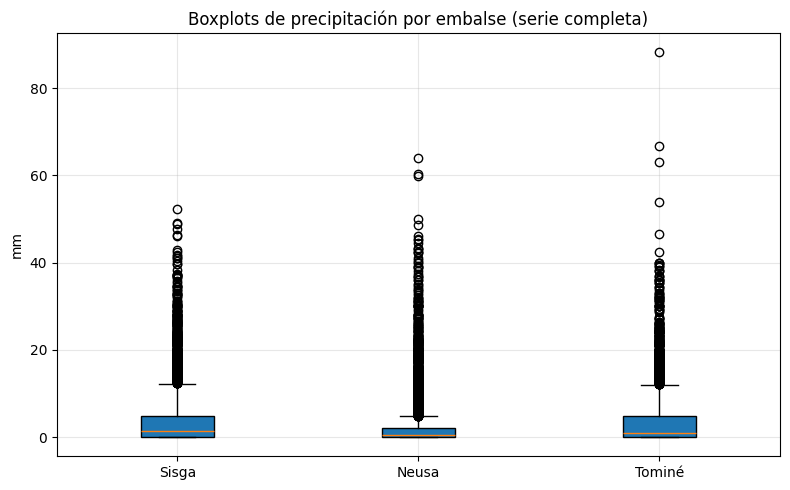

In [ ]:
# CARGA DE PRECIPITACIÓN (PR_Embalses.xlsx)
# PR_TOMINE es la estación principal (aprox 7.04 km de distancia).
# PR_TOMINE2 es la estación secundaria El Amoladero (aprox 15.11 km de distancia):
# se usa solo para rellenar los 84 días faltantes de PR_TOMINE.
# Ambas hojas tienen columnas: Fecha | Tomine_mm

df_pr_sisga   = pd.read_excel(ARCHIVO_PRECIP, sheet_name='PR_SISGA')
df_pr_neusa   = pd.read_excel(ARCHIVO_PRECIP, sheet_name='PR_NEUSA')
df_pr_tomine  = pd.read_excel(ARCHIVO_PRECIP, sheet_name='PR_TOMINE')
df_pr_tomine2 = pd.read_excel(ARCHIVO_PRECIP, sheet_name='PR_TOMINE2')

# Estandarizar nombres de columnas internamente
df_pr_sisga.columns   = ['Fecha', 'Precip_mm']
df_pr_neusa.columns   = ['Fecha', 'Precip_mm']
df_pr_tomine.columns  = ['Fecha', 'Precip_mm']
df_pr_tomine2.columns = ['Fecha', 'Precip_mm']

# Convertir tipos y limpiar
for df in (df_pr_sisga, df_pr_neusa, df_pr_tomine, df_pr_tomine2):
    df['Fecha']     = pd.to_datetime(df['Fecha'], errors='coerce')
    df['Precip_mm'] = pd.to_numeric(df['Precip_mm'], errors='coerce')
    df.replace(r'^\s*$', np.nan, regex=True, inplace=True)
    df.dropna(subset=['Fecha'], inplace=True)
    df.drop(index=df[~df['Fecha'].dt.year.between(1980, 2030)].index, inplace=True)

# Boxplot de comprobación de carga — precipitación
plt.figure(figsize=(8, 5))
plt.boxplot(
    [df_pr_sisga['Precip_mm'].dropna(),
     df_pr_neusa['Precip_mm'].dropna(),
     df_pr_tomine['Precip_mm'].dropna()],
    tick_labels=['Sisga', 'Neusa', 'Tominé'],
    patch_artist=True
)
plt.ylabel('mm')
plt.title('Boxplots de precipitación por embalse (serie completa)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RUTA_FIGURAS + 'boxplot_precipitacion_carga.png', dpi=150)
plt.show()

### Celda 06 — Filtrado al período de análisis

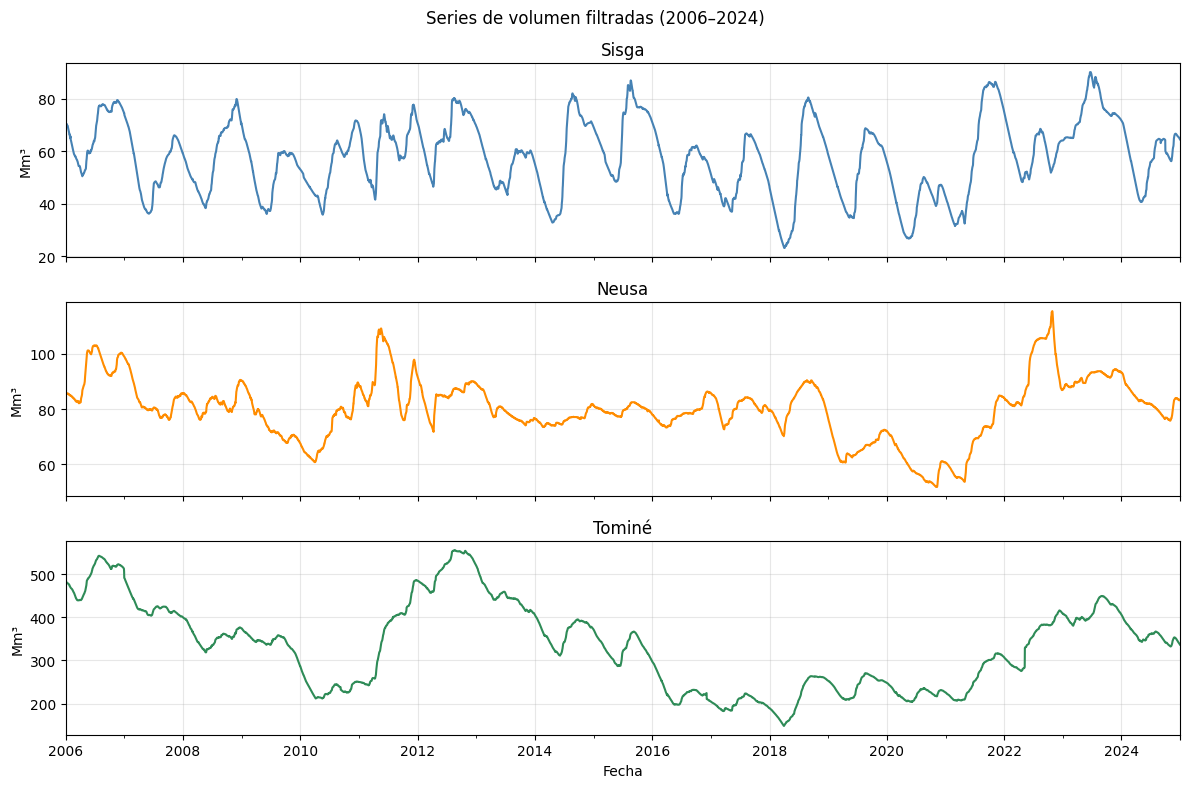

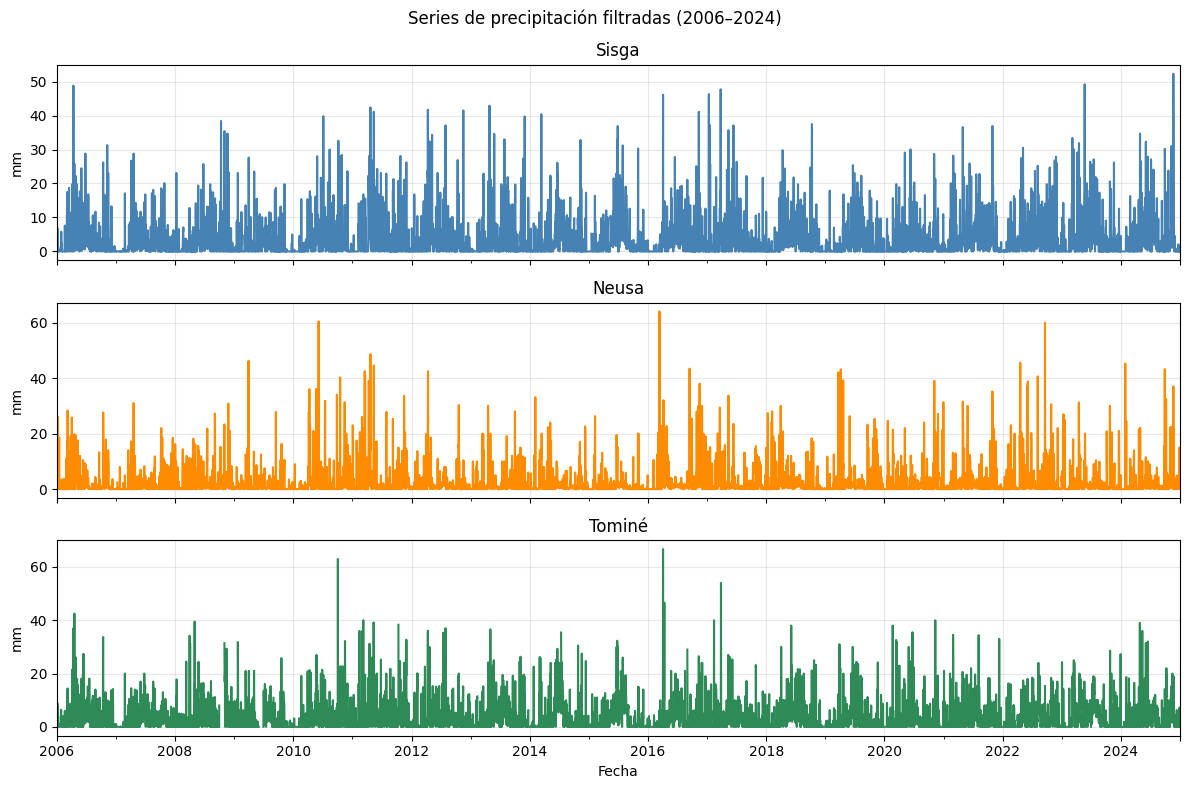

In [ ]:
# FILTRADO A LA VENTANA DE ANÁLISIS

sisga_vol_f  = df_sisga[(df_sisga['Fecha'] >= FECHA_INICIO)   & (df_sisga['Fecha'] <= FECHA_FIN)].copy()
neusa_vol_f  = df_neusa[(df_neusa['Fecha'] >= FECHA_INICIO)   & (df_neusa['Fecha'] <= FECHA_FIN)].copy()
tomine_vol_f = df_tomine[(df_tomine['Fecha'] >= FECHA_INICIO) & (df_tomine['Fecha'] <= FECHA_FIN)].copy()

sisga_pr_f   = df_pr_sisga[(df_pr_sisga['Fecha'] >= FECHA_INICIO)     & (df_pr_sisga['Fecha'] <= FECHA_FIN)].copy()
neusa_pr_f   = df_pr_neusa[(df_pr_neusa['Fecha'] >= FECHA_INICIO)     & (df_pr_neusa['Fecha'] <= FECHA_FIN)].copy()
tomine_pr_f  = df_pr_tomine[(df_pr_tomine['Fecha'] >= FECHA_INICIO)   & (df_pr_tomine['Fecha'] <= FECHA_FIN)].copy()
tomine2_pr_f = df_pr_tomine2[(df_pr_tomine2['Fecha'] >= FECHA_INICIO) & (df_pr_tomine2['Fecha'] <= FECHA_FIN)].copy()

# Poner Fecha como índice en todos
for df in (sisga_vol_f, neusa_vol_f, tomine_vol_f,
           sisga_pr_f, neusa_pr_f, tomine_pr_f, tomine2_pr_f):
    df.set_index('Fecha', inplace=True)
    df.sort_index(inplace=True)

# Reindexar al calendario diario completo para exponer días ausentes como NaN
calendario = pd.date_range(start=FECHA_INICIO, end=FECHA_FIN, freq='D')

sisga_vol_f   = sisga_vol_f.reindex(calendario).rename_axis('Fecha')
neusa_vol_f   = neusa_vol_f.reindex(calendario).rename_axis('Fecha')
tomine_vol_f  = tomine_vol_f.reindex(calendario).rename_axis('Fecha')
sisga_pr_f    = sisga_pr_f.reindex(calendario).rename_axis('Fecha')
neusa_pr_f    = neusa_pr_f.reindex(calendario).rename_axis('Fecha')
tomine_pr_f   = tomine_pr_f.reindex(calendario).rename_axis('Fecha')
tomine2_pr_f  = tomine2_pr_f.reindex(calendario).rename_axis('Fecha')

# Graficar series filtradas — volúmenes (NaN aparecen como cortes)
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
sisga_vol_f['Sisga_Mm3'].plot(ax=axes[0],   title='Sisga',   legend=False, color='steelblue')
neusa_vol_f['Neusa_Mm3'].plot(ax=axes[1],   title='Neusa',   legend=False, color='darkorange')
tomine_vol_f['Tomine_Mm3'].plot(ax=axes[2], title='Tominé',  legend=False, color='seagreen')
for ax in axes:
    ax.set_ylabel('Mm³')
    ax.grid(alpha=0.3)
fig.suptitle('Series de volumen filtradas (2006–2024)')
plt.tight_layout()
plt.savefig(RUTA_FIGURAS + 'series_volumenes_filtradas.png', dpi=150)
plt.show()

# Graficar series filtradas — precipitación
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
sisga_pr_f['Precip_mm'].plot(ax=axes[0],   title='Sisga',  legend=False, color='steelblue')
neusa_pr_f['Precip_mm'].plot(ax=axes[1],   title='Neusa',  legend=False, color='darkorange')
tomine_pr_f['Precip_mm'].plot(ax=axes[2],  title='Tominé', legend=False, color='seagreen')
for ax in axes:
    ax.set_ylabel('mm')
    ax.grid(alpha=0.3)
fig.suptitle('Series de precipitación filtradas (2006–2024)')
plt.tight_layout()
plt.savefig(RUTA_FIGURAS + 'series_precipitacion_filtradas.png', dpi=150)
plt.show()

### Celda 07 — Estadísticos descriptivos

In [ ]:
# ESTADÍSTICOS DESCRIPTIVOS

resumen_vol = pd.concat({
    'Sisga' : sisga_vol_f['Sisga_Mm3'].describe(),
    'Neusa' : neusa_vol_f['Neusa_Mm3'].describe(),
    'Tominé': tomine_vol_f['Tomine_Mm3'].describe(),
}, axis=1)

resumen_prec = pd.concat({
    'Sisga' : sisga_pr_f['Precip_mm'].describe(),
    'Neusa' : neusa_pr_f['Precip_mm'].describe(),
    'Tominé': tomine_pr_f['Precip_mm'].describe(),
}, axis=1)

print("Estadísticos descriptivos — Volumen (Mm³)")
print(resumen_vol.round(3))
print()
print("Estadísticos descriptivos — Precipitación (mm)")
print(resumen_prec.round(3))

Estadísticos descriptivos — Volumen (Mm³)
          Sisga     Neusa    Tominé
count  6921.000  6937.000  6935.000
mean     57.836    80.106   334.364
std      13.995    10.830    99.955
min      23.238    51.891   148.328
25%      47.450    74.791   238.955
50%      58.825    80.157   342.275
75%      67.735    85.944   406.621
max      90.122   115.333   555.881

Estadísticos descriptivos — Precipitación (mm)
          Sisga     Neusa    Tominé
count  6931.000  6923.000  6856.000
mean      3.669     2.397     3.443
std       5.740     5.238     5.752
min       0.000     0.000     0.000
25%       0.000     0.100     0.000
50%       1.300     0.500     0.900
75%       4.900     2.000     4.600
max      52.300    64.000    66.700


### Celda 08 — Diagnóstico de datos faltantes

In [ ]:
# DIAGNÓSTICO DE DATOS FALTANTES

# Diccionarios
dfs_vol = {
    'Sisga' : sisga_vol_f,
    'Neusa' : neusa_vol_f,
    'Tominé': tomine_vol_f,
}
col_vol = {
    'Sisga' : 'Sisga_Mm3',
    'Neusa' : 'Neusa_Mm3',
    'Tominé': 'Tomine_Mm3',
}

dfs_prec = {
    'Sisga' : sisga_pr_f,
    'Neusa' : neusa_pr_f,
    'Tominé': tomine_pr_f,   # estación principal; los faltantes se ven aquí
}

# Conteo de nulos — Volumen
print("\n── Nulos en VOLUMEN (ventana filtrada) " + "─"*30)
nulos_vol = {}
for name, df in dfs_vol.items():
    total  = len(df)
    faltan = df[col_vol[name]].isna().sum()
    pct    = faltan / total
    print(f"{name}({total}):\t{faltan} valores nulos \t({pct:.3%})")
    nulos_vol[name] = df[df[col_vol[name]].isna()].copy()

# Tablas de fechas con NaN en volumen
print("\nFechas con NaN — Volumen Sisga:");  print(nulos_vol['Sisga'])
print("\nFechas con NaN — Volumen Neusa:");  print(nulos_vol['Neusa'])
print("\nFechas con NaN — Volumen Tominé:"); print(nulos_vol['Tominé'])

# Conteo de nulos — Precipitación ──────
print("\n── Nulos en PRECIPITACIÓN estación principal " + "─"*10)
nulos_prec = {}
for name, df in dfs_prec.items():
    total  = len(df)
    faltan = df['Precip_mm'].isna().sum()
    pct    = faltan / total
    print(f"{name}({total}):\t{faltan} valores nulos \t({pct:.3%})")
    nulos_prec[name] = df[df['Precip_mm'].isna()].copy()

print("\nFechas con NaN — Precip Sisga:");  print(nulos_prec['Sisga'])
print("\nFechas con NaN — Precip Neusa:");  print(nulos_prec['Neusa'])
print("\nFechas con NaN — Precip Tominé (estación principal, 7.04 km):")
print(nulos_prec['Tominé'])


── Nulos en VOLUMEN (ventana filtrada) ──────────────────────────────
Sisga(6940):	19 valores nulos 	(0.274%)
Neusa(6940):	3 valores nulos 	(0.043%)
Tominé(6940):	5 valores nulos 	(0.072%)

Fechas con NaN — Volumen Sisga:
            Sisga_Mm3
Fecha                
2006-03-01        NaN
2007-03-01        NaN
2008-03-01        NaN
2009-03-01        NaN
2010-03-01        NaN
2011-03-01        NaN
2012-03-01        NaN
2013-03-01        NaN
2014-03-01        NaN
2015-03-01        NaN
2016-03-01        NaN
2017-03-01        NaN
2018-03-01        NaN
2019-03-01        NaN
2020-03-01        NaN
2021-03-01        NaN
2022-03-01        NaN
2023-03-01        NaN
2024-03-01        NaN

Fechas con NaN — Volumen Neusa:
            Neusa_Mm3
Fecha                
2022-01-07        NaN
2024-06-30        NaN
2024-09-30        NaN

Fechas con NaN — Volumen Tominé:
            Tomine_Mm3
Fecha                 
2008-02-29         NaN
2012-02-29         NaN
2016-02-29         NaN
2020-02-29         NaN


Dado la cantidad de valores faltantes en Tominé (1.210%) se emplea una estación secundaria que si contiene mediciones en esas fechas.

### Celda 09 — Relleno Tominé con estación secundaria

In [ ]:
# RELLENO TOMINÉ CON ESTACIÓN SECUNDARIA (PR_TOMINE2, 15.11 km)
# Se usa combine_first: conserva el valor de la estación principal cuando
# existe y solo toma TOMINE2 en los días donde la principal tiene NaN.
# Los 84 días faltantes quedan cubiertos al 100 % con esta operación.

print("\n Relleno Tominé con estación secundaria (El Amoladero, aprox. 15.11 km)")
n_antes = tomine_pr_f['Precip_mm'].isna().sum()

tomine_pr_f['Precip_mm'] = (
    tomine_pr_f['Precip_mm']
    .combine_first(tomine2_pr_f['Precip_mm'])
)

n_despues = tomine_pr_f['Precip_mm'].isna().sum()
print(f"Tominé — faltantes después del relleno: {n_despues}")

# Actualizar el diccionario con la serie ya rellenada
dfs_prec['Tominé'] = tomine_pr_f


 Relleno Tominé con estación secundaria (El Amoladero, aprox. 15.11 km)
Tominé — faltantes después del relleno: 0


### Celda 10 — Imputación por interpolación lineal

In [ ]:
# IMPUTACIÓN (interpolación lineal)
# Se aplica interpolación lineal + ffill/bfill para cubrir extremos

# Volumen
sisga_vol_f['Sisga_Mm3']    = sisga_vol_f['Sisga_Mm3'].interpolate('linear').ffill().bfill()
neusa_vol_f['Neusa_Mm3']    = neusa_vol_f['Neusa_Mm3'].interpolate('linear').ffill().bfill()
tomine_vol_f['Tomine_Mm3']  = tomine_vol_f['Tomine_Mm3'].interpolate('linear').ffill().bfill()

# Precipitación (gaps ≤ 2 días tras el relleno de TOMINE2)
sisga_pr_f['Precip_mm']   = sisga_pr_f['Precip_mm'].interpolate('linear').ffill().bfill()
neusa_pr_f['Precip_mm']   = neusa_pr_f['Precip_mm'].interpolate('linear').ffill().bfill()
tomine_pr_f['Precip_mm']  = tomine_pr_f['Precip_mm'].interpolate('linear').ffill().bfill()

# Verificación post-imputación
print("\n Verificación post-imputación VOLUMEN ")
for name, df, col in [('Sisga',  sisga_vol_f,  'Sisga_Mm3'),
                       ('Neusa',  neusa_vol_f,  'Neusa_Mm3'),
                       ('Tominé', tomine_vol_f, 'Tomine_Mm3')]:
    total  = len(df)
    faltan = df[col].isna().sum()
    pct    = faltan / total
    print(f"{name}({total}):\t{faltan} valores nulos \t({pct:.3%})")

print("\nVerificación post-imputación PRECIPITACIÓN ")
for name, df in [('Sisga',  sisga_pr_f),
                 ('Neusa',  neusa_pr_f),
                 ('Tominé', tomine_pr_f)]:
    total  = len(df)
    faltan = df['Precip_mm'].isna().sum()
    pct    = faltan / total
    print(f"{name}({total}):\t{faltan} valores nulos \t({pct:.3%})")


 Verificación post-imputación VOLUMEN 
Sisga(6940):	0 valores nulos 	(0.000%)
Neusa(6940):	0 valores nulos 	(0.000%)
Tominé(6940):	0 valores nulos 	(0.000%)

Verificación post-imputación PRECIPITACIÓN 
Sisga(6940):	0 valores nulos 	(0.000%)
Neusa(6940):	0 valores nulos 	(0.000%)
Tominé(6940):	0 valores nulos 	(0.000%)


### Celda 11 — Unir tabla de precipitación con volumen

In [ ]:
# VOLUMEN + PRECIPITACIÓN POR FECHA
# inner join sobre el índice Fecha → cada día tiene su volumen y su
# precipitación del mismo día, sin desfases

dfs_merged = {}
for name, df_v, col_v, df_p in [
        ('Sisga',  sisga_vol_f,  'Sisga_Mm3',  sisga_pr_f),
        ('Neusa',  neusa_vol_f,  'Neusa_Mm3',  neusa_pr_f),
        ('Tominé', tomine_vol_f, 'Tomine_Mm3', tomine_pr_f)]:

    merged = df_v[[col_v]].join(df_p[['Precip_mm']], how='inner')
    merged.columns = ['Volumen_Mm3', 'Precip_mm']
    dfs_merged[name] = merged

print("\n Resultado del merge ")
for name, df in dfs_merged.items():
    print(f"{name}({len(df)}):\t{df.isna().sum().sum()} NaN totales "
          f"| Vol [{df['Volumen_Mm3'].min():.1f}–{df['Volumen_Mm3'].max():.1f}] Mm³ "
          f"| Prec [{df['Precip_mm'].min():.1f}–{df['Precip_mm'].max():.1f}] mm")

# Verificación de alineación — el 5 de marzo de 2010
fecha_prueba = pd.Timestamp('2010-03-05')
print(f"\nVerificación alineación ({fecha_prueba.date()}):")
for name, df in dfs_merged.items():
    r = df.loc[fecha_prueba]
    print(f"  {name:7s} → Volumen: {r['Volumen_Mm3']:.3f} Mm³ | Precip: {r['Precip_mm']:.1f} mm")


 Resultado del merge 
Sisga(6940):	0 NaN totales | Vol [23.2–90.1] Mm³ | Prec [0.0–52.3] mm
Neusa(6940):	0 NaN totales | Vol [51.9–115.3] Mm³ | Prec [0.0–64.0] mm
Tominé(6940):	0 NaN totales | Vol [148.3–555.9] Mm³ | Prec [0.0–66.7] mm

Verificación alineación (2010-03-05):
  Sisga   → Volumen: 45.967 Mm³ | Precip: 0.0 mm
  Neusa   → Volumen: 62.535 Mm³ | Precip: 1.0 mm
  Tominé  → Volumen: 233.020 Mm³ | Precip: 1.0 mm


### Celda 12 — Exportar a Excel


In [ ]:
# EXPORTAR A EXCEL
# Genera Datos_base/Datos_Embalses_Merged.xlsx con una hoja por embalse
# Columnas: Fecha | Volumen_Mm3 | Precip_mm

ARCHIVO_SALIDA = RUTA_DATOS + 'Datos_Embalses_Merged.xlsx'

with pd.ExcelWriter(ARCHIVO_SALIDA, engine='openpyxl') as writer:
    for name, df in dfs_merged.items():
        nombre_hoja = name.replace('é', 'e')
        df_export = df.reset_index()
        df_export['Fecha'] = df_export['Fecha'].dt.date
        df_export.to_excel(writer, sheet_name=nombre_hoja, index=False)
        ws = writer.sheets[nombre_hoja]
        for col in ws.columns:
            ancho = max(len(str(c.value or '')) for c in col) + 3
            ws.column_dimensions[col[0].column_letter].width = min(ancho, 20)

print(f"\nArchivo guardado en: {ARCHIVO_SALIDA}")
print("Hojas:", [n.replace('é','e') for n in dfs_merged])


Archivo guardado en: /content/drive/MyDrive/Embalses/Datos_base/Datos_Embalses_Merged.xlsx
Hojas: ['Sisga', 'Neusa', 'Tomine']


In [ ]:
# El diccionario dfs_merged tiene la siguiente estructura:
#
#   dfs_merged['Sisga']   → DataFrame(índice=Fecha, Volumen_Mm3, Precip_mm)
#   dfs_merged['Neusa']   → ídem
#   dfs_merged['Tominé']  → ídem
#
# Para cargarlo desde el Excel en el notebook de redes (sin re-ejecutar
# todo el script):
#
#   dfs_merged = {}
#   for embalse, hoja in [('Sisga','Sisga'),('Neusa','Neusa'),('Tominé','Tomine')]:
#       df = pd.read_excel(RUTA_DATOS + 'Datos_Embalses_Merged.xlsx', sheet_name=hoja)
#       df['Fecha'] = pd.to_datetime(df['Fecha'])
#       dfs_merged[embalse] = df.set_index('Fecha')

### Celda 13 — Pruebas de estacionariedad (ADF / KPSS)

In [ ]:
for name, df in dfs_merged.items():

    print(f"{'='*40}")
    print(f"{name} — Volumen (Mm³)")
    serie_vol = df['Volumen_Mm3'].dropna()
    print("ADF: ", adfuller(serie_vol, autolag='AIC')[1])
    print("KPSS:", kpss(serie_vol, regression='c', nlags='auto')[1])

    print(f"\n{name} — Precipitación (mm)")
    serie_prec = df['Precip_mm'].dropna()
    print("ADF: ", adfuller(serie_prec, autolag='AIC')[1])
    print("KPSS:", kpss(serie_prec, regression='c', nlags='auto')[1])
    print()

Sisga — Volumen (Mm³)
ADF:  7.631921982621191e-10
KPSS: 0.1

Sisga — Precipitación (mm)


/tmp/ipykernel_4375/690834326.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  print("KPSS:", kpss(serie_vol, regression='c', nlags='auto')[1])


ADF:  3.101846884099299e-18
KPSS: 0.1

Neusa — Volumen (Mm³)


/tmp/ipykernel_4375/690834326.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  print("KPSS:", kpss(serie_prec, regression='c', nlags='auto')[1])


ADF:  0.0016545167462676234
KPSS: 0.01

Neusa — Precipitación (mm)


...

/tmp/ipykernel_4375/690834326.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  print("KPSS:", kpss(serie_prec, regression='c', nlags='auto')[1])


ADF:  0.11766525250143195
KPSS: 0.01

Tominé — Precipitación (mm)


/tmp/ipykernel_4375/690834326.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  print("KPSS:", kpss(serie_vol, regression='c', nlags='auto')[1])


ADF:  6.65176874935305e-20
KPSS: 0.1



/tmp/ipykernel_4375/690834326.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  print("KPSS:", kpss(serie_prec, regression='c', nlags='auto')[1])


## Fase 2 - Redes neuronales bivariadas (ΔVolumen + Precipitación)

La variable objetivo es ΔVol(t) = Vol(t) − Vol(t−1).
Las entradas son ventanas de [ΔVol, Precip_mm] de 30 días.
Para predecir ΔVol(t) solo se usa Precip hasta t−1 (sin fuga de información).

Métrica principal: Skill = MAE_modelo / MAE_Naive (Naive de deriva)

### Celda 14 — Semilla y función auxiliar

In [ ]:
# Semilla y función auxiliar

def fijar_semilla(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    try:
        tf.config.experimental.enable_op_determinism()
    except RuntimeError:
        pass

### Celda 15 — Validación de columnas en dfs_merged

In [ ]:
# Validación de columnas en dfs_merged

COLUMNAS_REQUERIDAS = ['Volumen_Mm3', 'Precip_mm']

for nombre, df in dfs_merged.items():
    faltantes = [c for c in COLUMNAS_REQUERIDAS if c not in df.columns]
    if faltantes:
        raise ValueError(f"{nombre}: faltan columnas {faltantes} en dfs_merged.")
    print(f"{nombre:8s} — OK | n={len(df)} | "
          f"Vol [{df['Volumen_Mm3'].min():.1f}–{df['Volumen_Mm3'].max():.1f}] Mm³ | "
          f"Precip [{df['Precip_mm'].min():.1f}–{df['Precip_mm'].max():.1f}] mm")

print("\nTodas las columnas requeridas presentes en dfs_merged ✓")

Sisga    — OK | n=6940 | Vol [23.2–90.1] Mm³ | Precip [0.0–52.3] mm
Neusa    — OK | n=6940 | Vol [51.9–115.3] Mm³ | Precip [0.0–64.0] mm
Tominé   — OK | n=6940 | Vol [148.3–555.9] Mm³ | Precip [0.0–66.7] mm

Todas las columnas requeridas presentes en dfs_merged ✓


### Celda 16 — Función crear_ventana bivariada

In [ ]:
# Función crear_ventana bivariada

def crear_ventana(data_vol: np.ndarray,
                  data_prec: np.ndarray,
                  ventana: int,
                  formato_3d: bool = False):
    """
    Construye pares (X, y) para predicción bivariada supervisada.

    Entradas
    --------
    data_vol  : array 1-D con ΔVolumen escalado  (longitud N)
    data_prec : array 1-D con Precip_mm escalado (longitud N)
                Ya desplazada un paso (Precip(t-1)) por el caller.
    ventana   : número de pasos de look-back
    formato_3d: True  → X con forma (muestras, ventana, 2) para LSTM
                False → X con forma (muestras, ventana*2)  para MLP

    Alineamiento temporal
    ---------------------
    Para predecir ΔVol(t) la ventana usa:
        ΔVol  [t-ventana … t-1]  (ventana pasos)
        Precip[t-ventana … t-1]  (ya es Precip(t-1) en el origen)
    La precipitación data_prec ya viene desplazada por el caller
    (shift(1)), de modo que data_prec[k] = Precip_mm original[k-1].
    """
    v = data_vol.flatten()
    p = data_prec.flatten()
    assert len(v) == len(p), "data_vol y data_prec deben tener la misma longitud"

    X, y = [], []
    for i in range(len(v) - ventana):
        bloque_vol  = v[i: i + ventana]
        bloque_prec = p[i: i + ventana]
        X.append(np.stack([bloque_vol, bloque_prec], axis=1))  # (ventana, 2)
        y.append(v[i + ventana])

    X = np.array(X)   # (muestras, ventana, 2)
    y = np.array(y)   # (muestras,)

    if not formato_3d:
        X = X.reshape(X.shape[0], -1)   # (muestras, ventana*2)

    return X, y

### Celda 17 — Arquitecturas y función de entrenamiento

In [ ]:
# Arquitecturas MLP y LSTM bivariadas + entrenar_modelo

# Arquitectura MLP

def _build_mlp(ventana: int) -> Sequential:
    """MLP: entrada plana (ventana * 2 features)."""
    return Sequential([
        Input(shape=(ventana * 2,)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1)
    ])

# Arquitectura LSTM

def _build_lstm(ventana: int, unidades: int = 50) -> Sequential:
    """LSTM apilada: entrada (ventana, 2)."""
    return Sequential([
        Input(shape=(ventana, 2)),
        LSTM(unidades, activation='tanh', return_sequences=True),
        LSTM(unidades // 2, activation='tanh'),
        Dense(25, activation='relu'),
        Dense(1)
    ])


# Diccionario de arquitecturas

ARQUITECTURAS = {
    'MLP':  {'builder': _build_mlp,  'formato_3d': False},
    'LSTM': {'builder': _build_lstm, 'formato_3d': True},
}

# Entrenar modelo
def entrenar_modelo(nombre_embalse: str,
                    dfs: dict,
                    arquitectura: str,
                    ventana: int = 30,
                    epochs: int = 100,
                    seed: int = 42,
                    loss: str = 'mse',
                    huber_delta: float = 1.0,
                    lr_scheduler: bool = False) -> dict:
    """
    Entrena `arquitectura` para predecir ΔVolumen(t) usando como entradas
    ventanas bivariadas de [ΔVol, Precip_mm].

    Alineamiento temporal anti-fuga
    --------------------------------
    Para predecir ΔVol(t) únicamente se usa Precip(t-1).
    La serie de precipitación se desplaza un paso (shift(1)) antes de
    construir las ventanas, garantizando que nunca se filtra Precip(t).

    Parámetros
    ----------
    loss        : 'mse' o 'huber'
    huber_delta : escala de ΔVolumen NORMALIZADO [0,1]
    lr_scheduler: si True, añade ReduceLROnPlateau

    Devuelve dict con métricas de VAL y TEST calculadas sobre volumen
    reconstruido: Vol_pred(t) = Vol_real(t-1) + ΔVol_pred(t).
    """
    fijar_semilla(seed)
    cfg = ARQUITECTURAS[arquitectura]
    formato_3d = cfg['formato_3d']

    df_embalse = dfs[nombre_embalse]
    dataset_abs   = df_embalse['Volumen_Mm3'].values.reshape(-1, 1).astype(float)
    precip_orig   = df_embalse['Precip_mm'].values.astype(float)

    # Primera diferencia del volumen
    dataset_delta = np.diff(dataset_abs, axis=0)          # longitud N-1
    n = len(dataset_delta)

    # Precipitación desplazada un paso para evitar fuga de información:
    # precip_shifted[k] = Precip_mm original[k]
    # (np.diff elimina el índice 0, por lo que el elemento k de dataset_delta
    #  corresponde a Vol[k+1]-Vol[k]; la precipitación contemporánea a ese
    #  target es Precip[k+1], que no debe usarse → usamos Precip[k] = precip_orig[k])
    precip_shifted = precip_orig[:n]   # Precip(t-1) respecto al target ΔVol(t)

    # Partición temporal
    train_raw = int(n * 0.70)
    val_raw   = int(n * 0.80)

    # Escalado independiente, ajustado solo con Train
    scaler_vol   = MinMaxScaler(feature_range=(0, 1))
    scaler_prec  = MinMaxScaler(feature_range=(0, 1))

    scaler_vol.fit(dataset_delta[:train_raw])
    scaler_prec.fit(precip_shifted[:train_raw].reshape(-1, 1))

    delta_scaled = scaler_vol.transform(dataset_delta).flatten()
    prec_scaled  = scaler_prec.transform(precip_shifted.reshape(-1, 1)).flatten()

    X, y = crear_ventana(delta_scaled, prec_scaled, ventana, formato_3d=formato_3d)

    train_size = train_raw - ventana
    val_size   = val_raw   - ventana

    X_train, y_train = X[:train_size],         y[:train_size]
    X_val,   y_val   = X[train_size:val_size], y[train_size:val_size]
    X_test,  y_test  = X[val_size:],           y[val_size:]

    model = cfg['builder'](ventana)

    loss_fn = 'mse' if loss == 'mse' else tf.keras.losses.Huber(delta=huber_delta)
    model.compile(optimizer='adam', loss=loss_fn)

    callbacks_list = [EarlyStopping(monitor='val_loss', patience=15 if lr_scheduler else 10,
                                     restore_best_weights=True, verbose=0)]
    if lr_scheduler:
        callbacks_list.append(
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=0)
        )

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=32,
                        validation_data=(X_val, y_val),
                        callbacks=callbacks_list, verbose=0)

    def _bloque(X_split, y_split, idx_inicio):
        """Métricas sobre volumen reconstruido para un split dado."""
        pred_delta_scaled = model.predict(X_split, verbose=0)
        pred_delta   = scaler_vol.inverse_transform(pred_delta_scaled).flatten()
        y_real_delta = scaler_vol.inverse_transform(y_split.reshape(-1, 1)).flatten()

        # Último valor de ΔVol escalado en la ventana → naive_delta
        if formato_3d:
            ultimo_scaled = X_split[:, -1, 0]   # canal 0 = ΔVol
        else:
            # MLP: ventana*2 features entrelazadas como
            # [ΔVol_0, Precip_0, ΔVol_1, Precip_1, ..., ΔVol_{ventana-1}, Precip_{ventana-1}]
            # El último ΔVol real está en la posición (ventana-1)*2,
            ultimo_scaled = X_split[:, (ventana - 1) * 2]
        naive_delta = scaler_vol.inverse_transform(ultimo_scaled.reshape(-1, 1)).flatten()

        idx = np.arange(idx_inicio, idx_inicio + len(X_split))
        vol_t_minus_1 = dataset_abs[idx].flatten()

        pred       = (vol_t_minus_1 + pred_delta).reshape(-1, 1)
        y_real     = (vol_t_minus_1 + y_real_delta).reshape(-1, 1)
        pred_naive = (vol_t_minus_1 + naive_delta).reshape(-1, 1)

        mae   = mean_absolute_error(y_real, pred)
        rmse  = np.sqrt(mean_squared_error(y_real, pred))
        mape  = np.mean(np.abs((y_real - pred) / y_real)) * 100
        r2    = r2_score(y_real, pred)
        residuales = (y_real - pred).flatten()

        mae_naive  = mean_absolute_error(y_real, pred_naive)
        rmse_naive = np.sqrt(mean_squared_error(y_real, pred_naive))
        mape_naive = np.mean(np.abs((y_real - pred_naive) / y_real)) * 100

        return {
            'pred_delta': pred_delta, 'y_real_delta': y_real_delta, 'naive_delta': naive_delta,
            'mae_delta': mean_absolute_error(y_real_delta, pred_delta),
            'r2_delta':  r2_score(y_real_delta, pred_delta),
            'vol_t_minus_1': vol_t_minus_1, 'y_real': y_real, 'pred': pred, 'pred_naive': pred_naive,
            'mae': mae, 'rmse': rmse, 'mape': mape, 'r2': r2, 'residuales': residuales,
            'mae_naive': mae_naive, 'rmse_naive': rmse_naive, 'mape_naive': mape_naive,
        }

    idx_val_inicio  = train_size + ventana
    idx_test_inicio = val_size   + ventana

    return {
        'model': model, 'scaler_vol': scaler_vol, 'scaler_prec': scaler_prec,
        'history': history, 'arquitectura': arquitectura, 'formato_3d': formato_3d,
        'ventana': ventana, 'seed': seed, 'loss': loss,
        'huber_delta': huber_delta if loss == 'huber' else None,
        'lr_scheduler': lr_scheduler,
        'dataset_abs': dataset_abs,
        'train_raw': train_raw, 'val_raw': val_raw,
        'train_size': train_size, 'val_size': val_size,
        'X_train': X_train, 'y_train': y_train,
        'X_val':   X_val,   'y_val':   y_val,
        'X_test':  X_test,  'y_test':  y_test,
        'val':  _bloque(X_val,  y_val,  idx_val_inicio),
        'test': _bloque(X_test, y_test, idx_test_inicio),
    }

### Celda 18 — Sistema de guardado incremental

In [ ]:
# Sistema de guardado incremental (pickle + modelos .keras)

# Ruta para guarda
RUTA_CHECKPOINTS = RUTA_FIGURAS + 'checkpoints/'
RUTA_MODELOS     = RUTA_CHECKPOINTS + 'models/'
os.makedirs(RUTA_MODELOS, exist_ok=True)


def guardar_completo(resultados_multi: dict, nombre_config: str) -> None:
    """Guarda pickle ligero + modelos Keras reales en archivos .keras separados."""
    ligero = {}
    for embalse, modelos in resultados_multi.items():
        ligero[embalse] = {}
        for arq, corridas in modelos.items():
            ligero[embalse][arq] = []
            for r in corridas:
                ruta_modelo = f'{RUTA_MODELOS}/{nombre_config}__{embalse}__{arq}__seed{r["seed"]}.keras'
                r['model'].save(ruta_modelo)
                r_ligero = {k: v for k, v in r.items() if k != 'model'}
                if hasattr(r_ligero.get('history'), 'history'):
                    r_ligero['history'] = r_ligero['history'].history
                ligero[embalse][arq].append(r_ligero)

    with open(f'{RUTA_CHECKPOINTS}/{nombre_config}.pkl', 'wb') as f:
        pickle.dump(ligero, f)
    n_modelos = sum(len(c) for m in ligero.values() for c in m.values())
    print(f"  Guardado: {nombre_config}.pkl + {n_modelos} modelos .keras")


def cargar_completo(nombre_config: str) -> dict:
    """Recarga el pickle ligero e inyecta los modelos Keras reales."""
    with open(f'{RUTA_CHECKPOINTS}/{nombre_config}.pkl', 'rb') as f:
        resultados = pickle.load(f)
    for embalse, modelos in resultados.items():
        for arq, corridas in modelos.items():
            for r in corridas:
                ruta_modelo = f'{RUTA_MODELOS}/{nombre_config}__{embalse}__{arq}__seed{r["seed"]}.keras'
                r['model'] = tf.keras.models.load_model(ruta_modelo)
    return resultados

### Celda 19 — Función entrenar_multisemilla

In [ ]:
# Función entrenar_multisemilla con ETA

def entrenar_multisemilla(dfs: dict,
                           arquitecturas: tuple = ('MLP', 'LSTM'),
                           embalses: list = None,
                           ventana: int = 30,
                           epochs: int = 100,
                           semillas: tuple = (42, 43, 44, 45, 46, 47, 48, 49, 50, 51),
                           loss: str = 'mse',
                           huber_delta: float = 1.0,
                           lr_scheduler: bool = False,
                           nombre_config: str = None) -> dict:
    """
    Entrena cada arquitectura para cada embalse con todas las semillas.
    Imprime progreso, tiempo por corrida y ETA.
    Si `nombre_config` se especifica, guarda automáticamente al terminar.
    """
    embalses = list(dfs.keys()) if embalses is None else embalses
    resultados = {emb: {arq: [] for arq in arquitecturas} for emb in embalses}

    total_corridas = len(embalses) * len(arquitecturas) * len(semillas)
    print(f"{'='*65}")
    print(f"  INICIO ENTRENAMIENTO (bivariado: ΔVol + Precip)")
    print(f"  Función de pérdida : {loss}" + (f" (delta={huber_delta})" if loss == 'huber' else ''))
    print(f"  Arquitecturas      : {list(arquitecturas)}")
    print(f"  Embalses           : {embalses}")
    print(f"  Semillas           : N={len(semillas)}")
    print(f"  Total entrenamientos: {total_corridas}")
    print(f"{'='*65}\n")

    t0_total = time.time()
    tiempos  = []
    corrida_actual = 0

    for embalse in embalses:
        print(f"\n{'='*60}\n  PROCESANDO: {embalse}\n{'='*60}")
        for s in semillas:
            for arq in arquitecturas:
                corrida_actual += 1
                t0 = time.time()
                r = entrenar_modelo(embalse, dfs, arquitectura=arq, ventana=ventana,
                                    epochs=epochs, seed=s, loss=loss,
                                    huber_delta=huber_delta, lr_scheduler=lr_scheduler)
                resultados[embalse][arq].append(r)
                dt = time.time() - t0
                tiempos.append(dt)
                eta_min = ((total_corridas - corrida_actual) * np.mean(tiempos)) / 60
                epocas = len(r['history'].history['loss'])
                print(f"  [{corrida_actual:3d}/{total_corridas}] "
                      f"Semilla {s} | {arq:5s} | "
                      f"MAE_test={r['test']['mae']:.3f} Mm³ | "
                      f"épocas={epocas:3d} | "
                      f"t={dt:.1f}s | ETA≈{eta_min:.1f} min")

    t_total = (time.time() - t0_total) / 60
    print(f"\n{'='*65}")
    print(f"  Entrenamiento completado en {t_total:.1f} min  "
          f"({t_total/60:.2f} h)")
    print(f"{'='*65}")

    if nombre_config is not None:
        guardar_completo(resultados, nombre_config)

    return resultados

### Celda 20 — Semillas globales

In [ ]:
# Semillas globales y delta Huber

SEMILLAS    = (42, 43, 44, 45, 46, 47, 48, 49, 50, 51)   # N=10
HUBER_DELTA = 0.15

### Celda 21 — Fase 1: entrenamiento con pérdida MSE

In [ ]:
# Fase 1 — loss='mse' (línea base), N=10 semillas, MLP + LSTM

print("FASE 1 — loss='mse' (línea base)\n")
t0_fase = time.time()

resultados_multi = entrenar_multisemilla(
    dfs_merged, arquitecturas=('MLP', 'LSTM'), ventana=30, epochs=100,
    semillas=SEMILLAS, loss='mse', nombre_config='v15_mse'
)

print(f"\nFase 1 completada en {(time.time()-t0_fase)/60:.1f} min")

FASE 1 — loss='mse' (línea base)

  INICIO ENTRENAMIENTO (bivariado: ΔVol + Precip)
  Función de pérdida : mse
  Arquitecturas      : ['MLP', 'LSTM']
  Embalses           : ['Sisga', 'Neusa', 'Tominé']
  Semillas           : N=10
  Total entrenamientos: 60


  PROCESANDO: Sisga
  [  1/60] Semilla 42 | MLP   | MAE_test=0.124 Mm³ | épocas= 28 | t=44.2s | ETA≈43.5 min
  [  2/60] Semilla 42 | LSTM  | MAE_test=0.097 Mm³ | épocas= 39 | t=75.8s | ETA≈58.0 min
  [  3/60] Semilla 43 | MLP   | MAE_test=0.126 Mm³ | épocas= 28 | t=25.1s | ETA≈46.0 min
  [  4/60] Semilla 43 | LSTM  | MAE_test=0.109 Mm³ | épocas= 18 | t=27.9s | ETA≈40.4 min
  [  5/60] Semilla 44 | MLP   | MAE_test=0.116 Mm³ | épocas= 27 | t=22.4s | ETA≈35.8 min
  [  6/60] Semilla 44 | LSTM  | MAE_test=0.097 Mm³ | épocas= 41 | t=61.6s | ETA≈38.6 min
  [  7/60] Semilla 45 | MLP   | MAE_test=0.111 Mm³ | épocas= 25 | t=21.7s | ETA≈35.2 min
  [  8/60] Semilla 45 | LSTM  | MAE_test=0.100 Mm³ | épocas= 30 | t=44.2s | ETA≈35.0 min
  [  9/60

### Celda 22 — Fase 2: entrenamiento con pérdida Huber

In [ ]:
# Fase 2 — loss='huber', delta=0.15

print(f"FASE 2 — loss='huber', delta={HUBER_DELTA}\n")
t0_fase = time.time()

resultados_multi_huber = entrenar_multisemilla(
    dfs_merged, arquitecturas=('MLP', 'LSTM'), ventana=30, epochs=100,
    semillas=SEMILLAS, loss='huber', huber_delta=HUBER_DELTA,
    nombre_config='v15_huber015'
)

print(f"\nFase 2 completada en {(time.time()-t0_fase)/60:.1f} min")

FASE 2 — loss='huber', delta=0.15

  INICIO ENTRENAMIENTO (bivariado: ΔVol + Precip)
  Función de pérdida : huber (delta=0.15)
  Arquitecturas      : ['MLP', 'LSTM']
  Embalses           : ['Sisga', 'Neusa', 'Tominé']
  Semillas           : N=10
  Total entrenamientos: 60


  PROCESANDO: Sisga
  [  1/60] Semilla 42 | MLP   | MAE_test=0.120 Mm³ | épocas= 21 | t=19.5s | ETA≈19.2 min
  [  2/60] Semilla 42 | LSTM  | MAE_test=0.097 Mm³ | épocas= 36 | t=51.7s | ETA≈34.4 min
  [  3/60] Semilla 43 | MLP   | MAE_test=0.113 Mm³ | épocas= 20 | t=18.0s | ETA≈28.3 min
  [  4/60] Semilla 43 | LSTM  | MAE_test=0.099 Mm³ | épocas= 28 | t=40.7s | ETA≈30.3 min
  [  5/60] Semilla 44 | MLP   | MAE_test=0.119 Mm³ | épocas= 28 | t=22.1s | ETA≈27.9 min
  [  6/60] Semilla 44 | LSTM  | MAE_test=0.099 Mm³ | épocas= 38 | t=55.2s | ETA≈31.1 min
  [  7/60] Semilla 45 | MLP   | MAE_test=0.107 Mm³ | épocas= 20 | t=17.0s | ETA≈28.3 min
  [  8/60] Semilla 45 | LSTM  | MAE_test=0.097 Mm³ | épocas= 27 | t=39.9s | ETA≈28

### Celda 23 — Fase 3: Huber + ReduceLROnPlateau

In [ ]:
# Fase 3 — loss='huber', delta=0.15 + ReduceLROnPlateau

print(f"FASE 3 — loss='huber', delta={HUBER_DELTA} + ReduceLROnPlateau\n")
t0_fase = time.time()

resultados_multi_huber_lr = entrenar_multisemilla(
    dfs_merged, arquitecturas=('MLP', 'LSTM'), ventana=30, epochs=100,
    semillas=SEMILLAS, loss='huber', huber_delta=HUBER_DELTA, lr_scheduler=True,
    nombre_config='v15_huber015_lr'
)

print(f"\nFase 3 completada en {(time.time()-t0_fase)/60:.1f} min")

FASE 3 — loss='huber', delta=0.15 + ReduceLROnPlateau

  INICIO ENTRENAMIENTO (bivariado: ΔVol + Precip)
  Función de pérdida : huber (delta=0.15)
  Arquitecturas      : ['MLP', 'LSTM']
  Embalses           : ['Sisga', 'Neusa', 'Tominé']
  Semillas           : N=10
  Total entrenamientos: 60


  PROCESANDO: Sisga
  [  1/60] Semilla 42 | MLP   | MAE_test=0.114 Mm³ | épocas=100 | t=76.0s | ETA≈74.8 min
  [  2/60] Semilla 42 | LSTM  | MAE_test=0.093 Mm³ | épocas= 91 | t=125.3s | ETA≈97.3 min
  [  3/60] Semilla 43 | MLP   | MAE_test=0.113 Mm³ | épocas= 39 | t=31.5s | ETA≈73.7 min
  [  4/60] Semilla 43 | LSTM  | MAE_test=0.093 Mm³ | épocas= 54 | t=76.5s | ETA≈72.2 min
  [  5/60] Semilla 44 | MLP   | MAE_test=0.107 Mm³ | épocas= 48 | t=38.4s | ETA≈63.8 min
  [  6/60] Semilla 44 | LSTM  | MAE_test=0.094 Mm³ | épocas=100 | t=143.7s | ETA≈73.7 min
  [  7/60] Semilla 45 | MLP   | MAE_test=0.109 Mm³ | épocas= 24 | t=18.7s | ETA≈64.4 min
  [  8/60] Semilla 45 | LSTM  | MAE_test=0.094 Mm³ | épocas=

### Celda 24 — Corrección de comparaciones múltiples (Holm-Bonferroni)

In [ ]:
# Holm-Bonferroni

def holm_bonferroni(pvalues: list, alpha: float = 0.05):
    """Devuelve (p_ajustados, rechazos) usando el método de Holm-Bonferroni."""
    pvalues = np.asarray(pvalues, dtype=float)
    m = len(pvalues)
    orden = np.argsort(pvalues)
    ajustados = np.empty(m)
    p_prev = 0.0
    for rank, idx in enumerate(orden):
        ajustado = min((m - rank) * pvalues[idx], 1.0)
        ajustado = max(ajustado, p_prev)
        ajustados[idx] = ajustado
        p_prev = ajustado
    rechazos = ajustados < alpha
    return ajustados, rechazos

### Celda 25 — Selección de configuración ganadora (Wilcoxon + Holm-Bonferroni)

In [ ]:
# Selección de configuración de pérdida
# Criterio: MAE en VALIDACIÓN (Mm³), Wilcoxon pareado N=10, Holm-Bonferroni.
# El test no participa en ninguna decisión de selección.

def _mae_val_por_semilla(corridas: list) -> np.ndarray:
    return np.array([r['val']['mae'] for r in corridas])


def seleccionar_configuracion(configs: dict, dfs: dict,
                               baseline: str = 'mse',
                               alpha: float = 0.05) -> tuple:
    embalses      = list(dfs.keys())
    arquitecturas = list(next(iter(configs.values()))[embalses[0]].keys())
    candidatos    = [c for c in configs if c != baseline]

    seleccion      = {}
    filas_detalle  = []

    for embalse in embalses:
        seleccion[embalse] = {}
        for arq in arquitecturas:
            maes = {nombre: _mae_val_por_semilla(configs[nombre][embalse][arq])
                    for nombre in configs}

            p_raw = []
            for c in candidatos:
                try:
                    _, p = wilcoxon(maes[c], maes[baseline])
                except ValueError:
                    p = np.nan
                p_raw.append(p)

            p_validos = [p if not np.isnan(p) else 1.0 for p in p_raw]
            p_adj, rechazos = holm_bonferroni(p_validos, alpha=alpha)

            for c, p_r, p_a, rech in zip(candidatos, p_raw, p_adj, rechazos):
                filas_detalle.append({
                    'Embalse': embalse, 'Arquitectura': arq, 'Config': c,
                    'MAE val candidato (media)': np.mean(maes[c]),
                    'MAE val MSE (media)':       np.mean(maes[baseline]),
                    'Δ MAE (candidato − MSE)':   np.mean(maes[c]) - np.mean(maes[baseline]),
                    'p crudo (vs MSE)':          p_r,
                    'p ajustado (Holm)':         p_a,
                    'Significativo (α=0.05)':    bool(rech),
                    'Candidato mejora a MSE':    bool(rech and np.mean(maes[c]) < np.mean(maes[baseline])),
                })

            ganador   = baseline
            mejor_mae = np.mean(maes[baseline])
            for c, p_a, rech in zip(candidatos, p_adj, rechazos):
                mae_c = np.mean(maes[c])
                if rech and mae_c < mejor_mae:
                    ganador, mejor_mae = c, mae_c

            seleccion[embalse][arq] = {
                'config_ganadora': ganador,
                'corridas':        configs[ganador][embalse][arq],
                'mae_val_medio':   mejor_mae,
            }

    df_detalle = pd.DataFrame(filas_detalle)
    return seleccion, df_detalle


CONFIGS = {
    'mse':      resultados_multi,
    'huber':    resultados_multi_huber,
    'huber_lr': resultados_multi_huber_lr,
}
seleccion, df_seleccion_detalle = seleccionar_configuracion(CONFIGS, dfs_merged, baseline='mse')

print("DETALLE DE LA SELECCIÓN DE CONFIGURACIÓN")
print("Criterio: MAE en VALIDACIÓN (Mm³) — Wilcoxon pareado N=10, Holm-Bonferroni")
print("Δ MAE negativo = candidato mejora a MSE  |  Significativo = mejora estadísticamente robusta")
print("=" * 100)
print(df_seleccion_detalle.round(4).to_string(index=False))

print("\nCONFIGURACIÓN GANADORA POR EMBALSE Y ARQUITECTURA")
print("=" * 55)
for embalse, por_arq in seleccion.items():
    for arq, info in por_arq.items():
        print(f"  {embalse:8s} | {arq:5s} -> {info['config_ganadora']:9s} "
              f"(MAE val medio = {info['mae_val_medio']:.4f} Mm³)")

df_seleccion_detalle.to_csv(f'{RUTA_FIGURAS}/Table_Seleccion_Configuracion.csv', index=False)

DETALLE DE LA SELECCIÓN DE CONFIGURACIÓN
Criterio: MAE en VALIDACIÓN (Mm³) — Wilcoxon pareado N=10, Holm-Bonferroni
Δ MAE negativo = candidato mejora a MSE  |  Significativo = mejora estadísticamente robusta
Embalse Arquitectura   Config  MAE val candidato (media)  MAE val MSE (media)  Δ MAE (candidato − MSE)  p crudo (vs MSE)  p ajustado (Holm)  Significativo (α=0.05)  Candidato mejora a MSE
  Sisga          MLP    huber                     0.0916               0.0971                  -0.0056            0.0039             0.0039                    True                    True
  Sisga          MLP huber_lr                     0.0874               0.0971                  -0.0098            0.0020             0.0039                    True                    True
  Sisga         LSTM    huber                     0.0793               0.0808                  -0.0016            0.1309             0.1309                   False                   False
  Sisga         LSTM huber_lr           

### Celda 26 — Tabla resumen final (TEST)

In [ ]:
# Tabla resumen final por embalse y arquitectura (TEST)

def construir_tabla_resumen(seleccion: dict) -> pd.DataFrame:
    filas = []
    for embalse, por_arq in seleccion.items():
        for arq, info in por_arq.items():
            corridas  = info['corridas']
            maes      = np.array([r['test']['mae']  for r in corridas])
            rmses     = np.array([r['test']['rmse'] for r in corridas])
            mapes     = np.array([r['test']['mape'] for r in corridas])
            mae_naive = corridas[0]['test']['mae_naive']
            skills    = maes / mae_naive

            try:
                stat, p_vs_naive = wilcoxon(maes - mae_naive)
            except ValueError:
                stat, p_vs_naive = np.nan, np.nan

            filas.append({
                'Embalse': embalse, 'Arquitectura': arq,
                'Config ganadora':   info['config_ganadora'],
                'N semillas':        len(corridas),
                'MAE (media±DE)':    f"{maes.mean():.3f} ± {maes.std():.3f}",
                'RMSE (media±DE)':   f"{rmses.mean():.3f} ± {rmses.std():.3f}",
                'MAPE % (media±DE)': f"{mapes.mean():.2f} ± {mapes.std():.2f}",
                'MAE Naive (deriva)': f"{mae_naive:.3f}",
                'Skill (media±DE)':  f"{skills.mean():.4f} ± {skills.std():.4f}",
                'Wilcoxon stat (vs Naive)': f"{stat:.3f}" if not np.isnan(stat) else "N/A",
                'Wilcoxon p (vs Naive)':    f"{p_vs_naive:.4f}" if not np.isnan(p_vs_naive) else "N/A",
                'Conclusión vs Naive': ('Supera al Naive ✓'
                                        if (not np.isnan(p_vs_naive) and p_vs_naive < 0.05
                                            and skills.mean() < 1)
                                        else 'No se diferencia / no supera al Naive'),
            })
    return pd.DataFrame(filas)


df_resumen_final = construir_tabla_resumen(seleccion)
print("TABLA RESUMEN FINAL — TEST (N=10 semillas por configuración ganadora)")
print("=" * 100)
print(df_resumen_final.to_string(index=False))

df_resumen_final.to_csv(f'{RUTA_FIGURAS}/Table_Resumen_Final_Test.csv', index=False)

TABLA RESUMEN FINAL — TEST (N=10 semillas por configuración ganadora)
Embalse Arquitectura Config ganadora  N semillas MAE (media±DE) RMSE (media±DE) MAPE % (media±DE) MAE Naive (deriva) Skill (media±DE) Wilcoxon stat (vs Naive) Wilcoxon p (vs Naive)                   Conclusión vs Naive
  Sisga          MLP        huber_lr          10  0.109 ± 0.003   0.206 ± 0.004       0.18 ± 0.00              0.106  1.0317 ± 0.0270                    1.000                0.0039 No se diferencia / no supera al Naive
  Sisga         LSTM        huber_lr          10  0.093 ± 0.001   0.194 ± 0.000       0.15 ± 0.00              0.106  0.8784 ± 0.0053                    0.000                0.0020                     Supera al Naive ✓
  Neusa          MLP        huber_lr          10  0.080 ± 0.002   0.134 ± 0.004       0.09 ± 0.00              0.075  1.0700 ± 0.0256                    0.000                0.0020 No se diferencia / no supera al Naive
  Neusa         LSTM             mse          10  0.07

### Celda 27 — Comparación entre arquitecturas (MLP vs LSTM)

**Criterio de selección**: MAE individual de TEST (10 semillas por configuración
ganadora), comparado con Wilcoxon pareado + Holm-Bonferroni entre embalses.
Esta es la única comparación con respaldo estadístico formal del pipeline;
el ensemble por mediana (Celda 28) se calcula *después* de esta decisión y
no participa en ella — ver nota en Celda 28.

In [ ]:
# Comparación de arquitecturas (MLP vs LSTM)
# Wilcoxon pareado sobre MAE de TEST, Holm-Bonferroni a través de los 3 embalses.

def comparar_arquitecturas(seleccion: dict, alpha: float = 0.05) -> tuple:
    filas    = []
    p_raw    = []
    embalses = list(seleccion.keys())

    for embalse in embalses:
        maes_mlp  = np.array([r['test']['mae'] for r in seleccion[embalse]['MLP']['corridas']])
        maes_lstm = np.array([r['test']['mae'] for r in seleccion[embalse]['LSTM']['corridas']])
        try:
            stat, p = wilcoxon(maes_mlp, maes_lstm)
        except ValueError:
            stat, p = np.nan, np.nan
        p_raw.append(p if not np.isnan(p) else 1.0)
        filas.append({'Embalse': embalse,
                      'MAE MLP (media)':  maes_mlp.mean(),
                      'MAE LSTM (media)': maes_lstm.mean(),
                      'Wilcoxon stat': stat, 'p crudo': p})

    p_adj, rechazos = holm_bonferroni(p_raw, alpha=alpha)
    mejor_por_embalse = {}
    for fila, p_a, rech in zip(filas, p_adj, rechazos):
        fila['p ajustado (Holm)'] = p_a
        if rech:
            ganador = 'MLP' if fila['MAE MLP (media)'] < fila['MAE LSTM (media)'] else 'LSTM'
        else:
            ganador = 'Empate (p≥0.05)'
        fila['Ganador'] = ganador
        mejor_por_embalse[fila['Embalse']] = (ganador if ganador != 'Empate (p≥0.05)'
                                               else ('MLP' if fila['MAE MLP (media)'] < fila['MAE LSTM (media)']
                                                     else 'LSTM'))

    return pd.DataFrame(filas), mejor_por_embalse


df_arquitecturas, mejor_por_embalse = comparar_arquitecturas(seleccion)

print("COMPARACIÓN MLP vs LSTM (cada una en su configuración ganadora) — TEST, N=10, Holm-Bonferroni")
print("=" * 95)
print(df_arquitecturas.round(4).to_string(index=False))
print()
for embalse, ganador in mejor_por_embalse.items():
    empató = (df_arquitecturas.loc[df_arquitecturas['Embalse'] == embalse, 'Ganador'].iloc[0]
              == 'Empate (p≥0.05)')
    etiqueta = (f"{ganador} (sin diferencia estadísticamente significativa frente al otro)"
                if empató else ganador)
    print(f"  {embalse}: mejor modelo -> {etiqueta}")

df_arquitecturas.to_csv(f'{RUTA_FIGURAS}/Table_Comparacion_Arquitecturas.csv', index=False)

COMPARACIÓN MLP vs LSTM (cada una en su configuración ganadora) — TEST, N=10, Holm-Bonferroni
Embalse  MAE MLP (media)  MAE LSTM (media)  Wilcoxon stat  p crudo  p ajustado (Holm) Ganador
  Sisga           0.1094            0.0932            0.0   0.0020             0.0059    LSTM
  Neusa           0.0803            0.0728            0.0   0.0020             0.0059    LSTM
 Tominé           0.3408            0.3196            3.0   0.0098             0.0098    LSTM

  Sisga: mejor modelo -> LSTM
  Neusa: mejor modelo -> LSTM
  Tominé: mejor modelo -> LSTM


### Celda 28 — Ensemble por mediana

In [ ]:
# Ensemble (mediana de las 10 semillas) de la configuración ganadora

def construir_ensemble(corridas: list, metodo: str = 'mediana') -> dict:
    pred_deltas     = np.stack([r['test']['pred_delta'] for r in corridas])
    pred_delta_ens  = (np.median(pred_deltas, axis=0) if metodo == 'mediana'
                       else pred_deltas.mean(axis=0))

    ref            = corridas[0]['test']
    vol_t_minus_1  = ref['vol_t_minus_1']
    y_real_delta   = ref['y_real_delta']
    naive_delta    = ref['naive_delta']
    mae_naive, rmse_naive, mape_naive = ref['mae_naive'], ref['rmse_naive'], ref['mape_naive']

    pred_vol_ens   = (vol_t_minus_1 + pred_delta_ens).reshape(-1, 1)
    y_real_vol     = (vol_t_minus_1 + y_real_delta).reshape(-1, 1)
    pred_naive_vol = (vol_t_minus_1 + naive_delta).reshape(-1, 1)

    mae  = mean_absolute_error(y_real_vol, pred_vol_ens)
    rmse = np.sqrt(mean_squared_error(y_real_vol, pred_vol_ens))
    mape = np.mean(np.abs((y_real_vol - pred_vol_ens) / y_real_vol)) * 100
    r2   = r2_score(y_real_vol, pred_vol_ens)
    residuales = (y_real_vol - pred_vol_ens).flatten()

    return {
        'y_real': y_real_vol, 'pred': pred_vol_ens, 'pred_naive': pred_naive_vol,
        'mae': mae, 'rmse': rmse, 'mape': mape, 'r2': r2,
        'mae_naive': mae_naive, 'rmse_naive': rmse_naive, 'mape_naive': mape_naive,
        'residuales': residuales,
        'seed': f"ensemble {metodo} (N={len(corridas)})",
        'metodo': metodo, 'n_semillas': len(corridas),
    }


corridas_ganadoras = {}
corridas_finales   = {}
for embalse in dfs_merged.keys():
    corridas_ganadoras[embalse] = {}
    corridas_finales[embalse]   = {}
    for arq in ['MLP', 'LSTM']:
        corridas = seleccion[embalse][arq]['corridas']
        corridas_ganadoras[embalse][arq] = corridas
        corridas_finales[embalse][arq]   = construir_ensemble(corridas, metodo='mediana')

print("ENSEMBLE POR MEDIANA — configuración ganadora por embalse/arquitectura")
print("=" * 78)
filas_ens = []
for embalse in dfs_merged.keys():
    for arq in ['MLP', 'LSTM']:
        ens  = corridas_finales[embalse][arq]
        maes = [r['test']['mae'] for r in corridas_ganadoras[embalse][arq]]
        skill_ensemble = ens['mae'] / ens['mae_naive']
        filas_ens.append({
            'Embalse': embalse, 'Arquitectura': arq,
            'Config': seleccion[embalse][arq]['config_ganadora'],
            'MAE individual (media)':    np.mean(maes),
            'MAE ensemble (mediana)':    ens['mae'],
            'RMSE ensemble (mediana)':   ens['rmse'],
            'Skill ensemble (mediana)':  skill_ensemble,
            '¿Supera al Naive? (ensemble)': 'Sí ✓' if skill_ensemble < 1 else 'No ✗',
            '¿Mediana mejora al promedio individual?': 'Sí' if ens['mae'] < np.mean(maes) else 'No',
        })
df_ensemble = pd.DataFrame(filas_ens)
print(df_ensemble.round(4).to_string(index=False))
df_ensemble.to_csv(f'{RUTA_FIGURAS}/Table_Ensemble.csv', index=False)

print()
print("NOTA METODOLÓGICA:")
print("La arquitectura ganadora por embalse (MLP vs LSTM) se determinó en la")
print("Celda 27 comparando el MAE INDIVIDUAL promedio de las 10 semillas")
print("(Wilcoxon pareado + Holm-Bonferroni) — esa comparación NO usa el ensemble.")
print()
print("Una vez decidida la arquitectura ganadora, TODO lo reportado de aquí en")
print("adelante (Celdas 29-33: predicciones, figura de mejor modelo, residuales")
print("y Ljung-Box) corresponde al ENSEMBLE POR MEDIANA de esa arquitectura,")
print("no al promedio individual. Por eso el MAE reportado en Celdas 30-33")
print("(p.ej. 0.3115 para Tominé-LSTM) difiere ligeramente del MAE individual")
print("mostrado en la Celda 27 (0.3196) — son dos métricas distintas y ambas")
print("son correctas, cada una para su propio propósito: selección vs. reporte.")

ENSEMBLE POR MEDIANA — configuración ganadora por embalse/arquitectura
Embalse Arquitectura   Config  MAE individual (media)  MAE ensemble (mediana)  RMSE ensemble (mediana)  Skill ensemble (mediana) ¿Supera al Naive? (ensemble) ¿Mediana mejora al promedio individual?
  Sisga          MLP huber_lr                  0.1094                  0.0991                   0.1969                    0.9344                         Sí ✓                                      Sí
  Sisga         LSTM huber_lr                  0.0932                  0.0929                   0.1935                    0.8754                         Sí ✓                                      Sí
  Neusa          MLP huber_lr                  0.0803                  0.0757                   0.1281                    1.0090                         No ✗                                      Sí
  Neusa         LSTM      mse                  0.0728                  0.0719                   0.1229                    0.9579         

### Celda 29 — Curvas loss / val_loss

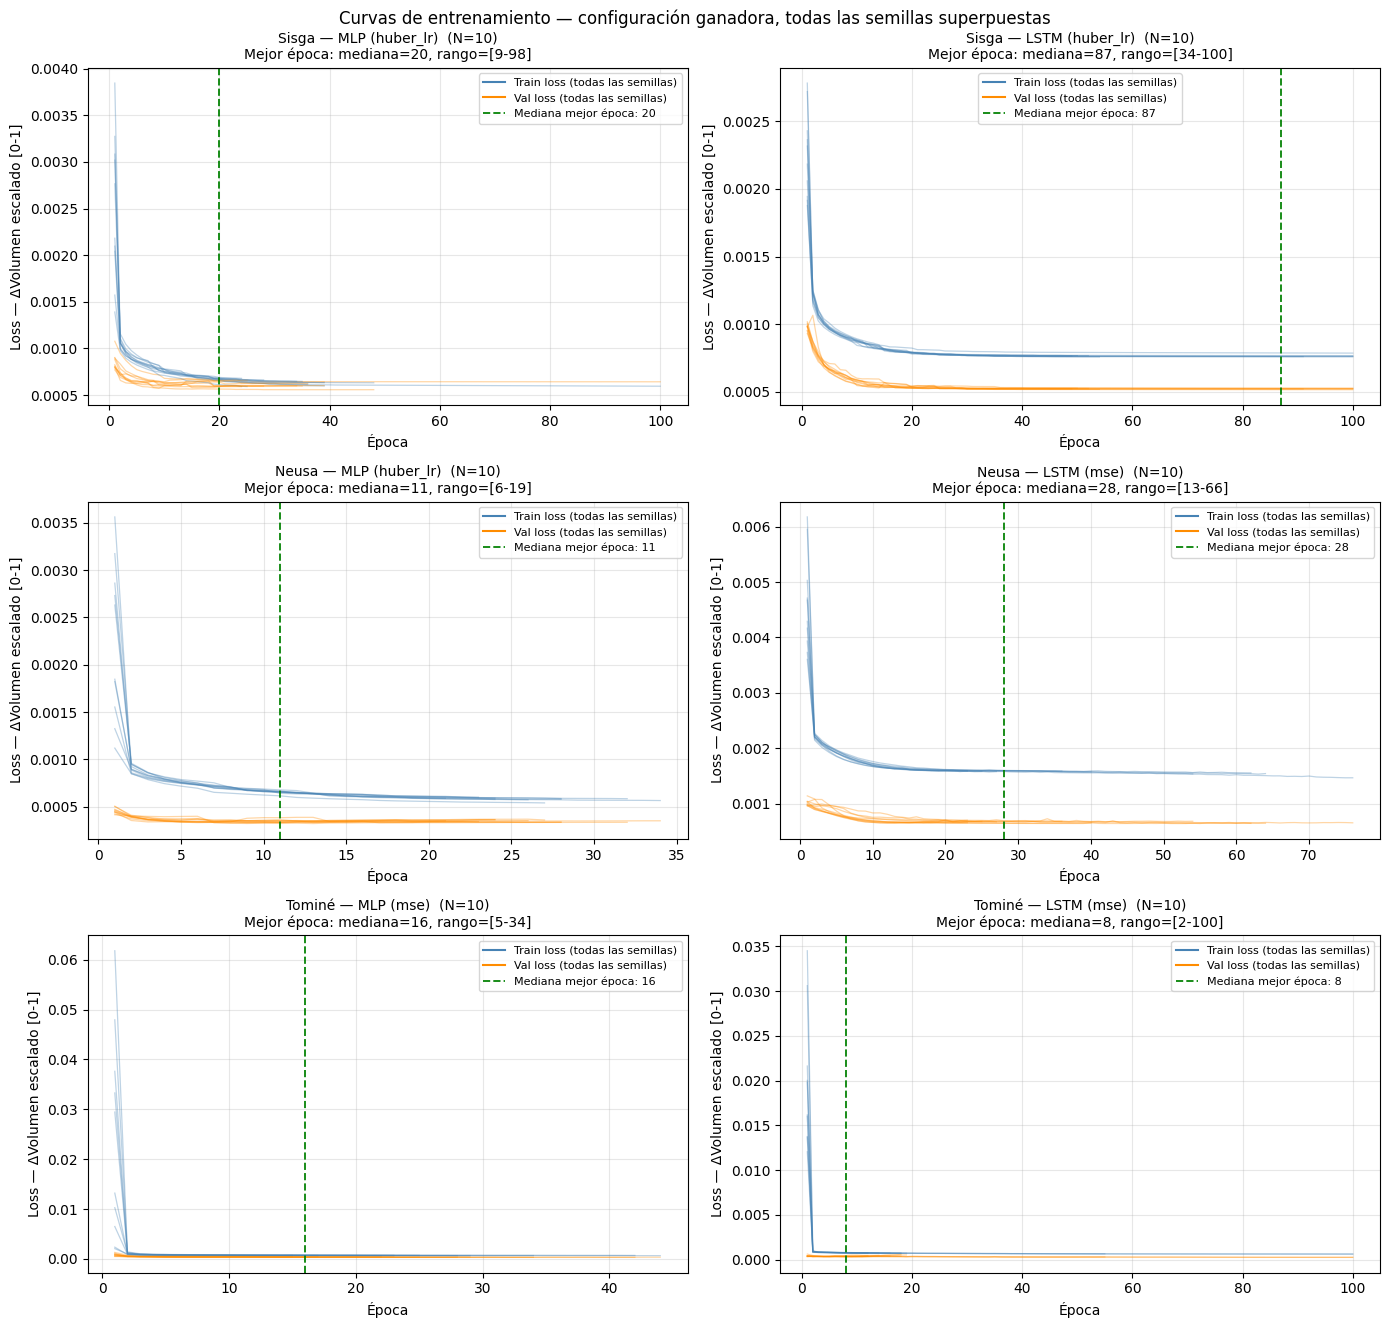

Figura guardada -> Figure_LossCurves.pdf


In [ ]:
# Curvas loss / val_loss — configuración ganadora

n_embalses = len(dfs_merged)
fig, axes = plt.subplots(n_embalses, 2, figsize=(14, 4.5 * n_embalses))
axes = np.atleast_2d(axes)

for fila, embalse in enumerate(dfs_merged.keys()):
    for col, arq in enumerate(['MLP', 'LSTM']):
        corridas = corridas_ganadoras[embalse][arq]
        config   = seleccion[embalse][arq]['config_ganadora']
        ax       = axes[fila, col]
        mejores_epocas = []
        for r in corridas:
            hist = r['history'].history if hasattr(r['history'], 'history') else r['history']
            ep   = range(1, len(hist['loss']) + 1)
            ax.plot(ep, hist['loss'],     color='steelblue',  linewidth=0.9, alpha=0.35)
            ax.plot(ep, hist['val_loss'], color='darkorange', linewidth=0.9, alpha=0.35)
            mejores_epocas.append(int(np.argmin(hist['val_loss'])) + 1)

        ax.plot([], [], color='steelblue',  linewidth=1.5, label='Train loss (todas las semillas)')
        ax.plot([], [], color='darkorange', linewidth=1.5, label='Val loss (todas las semillas)')
        mediana_ep = int(np.median(mejores_epocas))
        ax.axvline(mediana_ep, color='green', linestyle='--', linewidth=1.4, alpha=0.9,
                   label=f'Mediana mejor época: {mediana_ep}')
        ax.set_title(f'{embalse} — {arq} ({config})  (N={len(corridas)})\n'
                     f'Mejor época: mediana={mediana_ep}, '
                     f'rango=[{min(mejores_epocas)}-{max(mejores_epocas)}]', fontsize=10)
        ax.set_xlabel('Época')
        ax.set_ylabel('Loss — ΔVolumen escalado [0-1]')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

plt.suptitle('Curvas de entrenamiento — configuración ganadora, todas las semillas superpuestas',
             fontsize=12)
plt.tight_layout()
plt.savefig(f'{RUTA_FIGURAS}/Figure_LossCurves.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()
print("Figura guardada -> Figure_LossCurves.pdf")

### Celda 30 — Predicciones vs. valores reales (TEST)

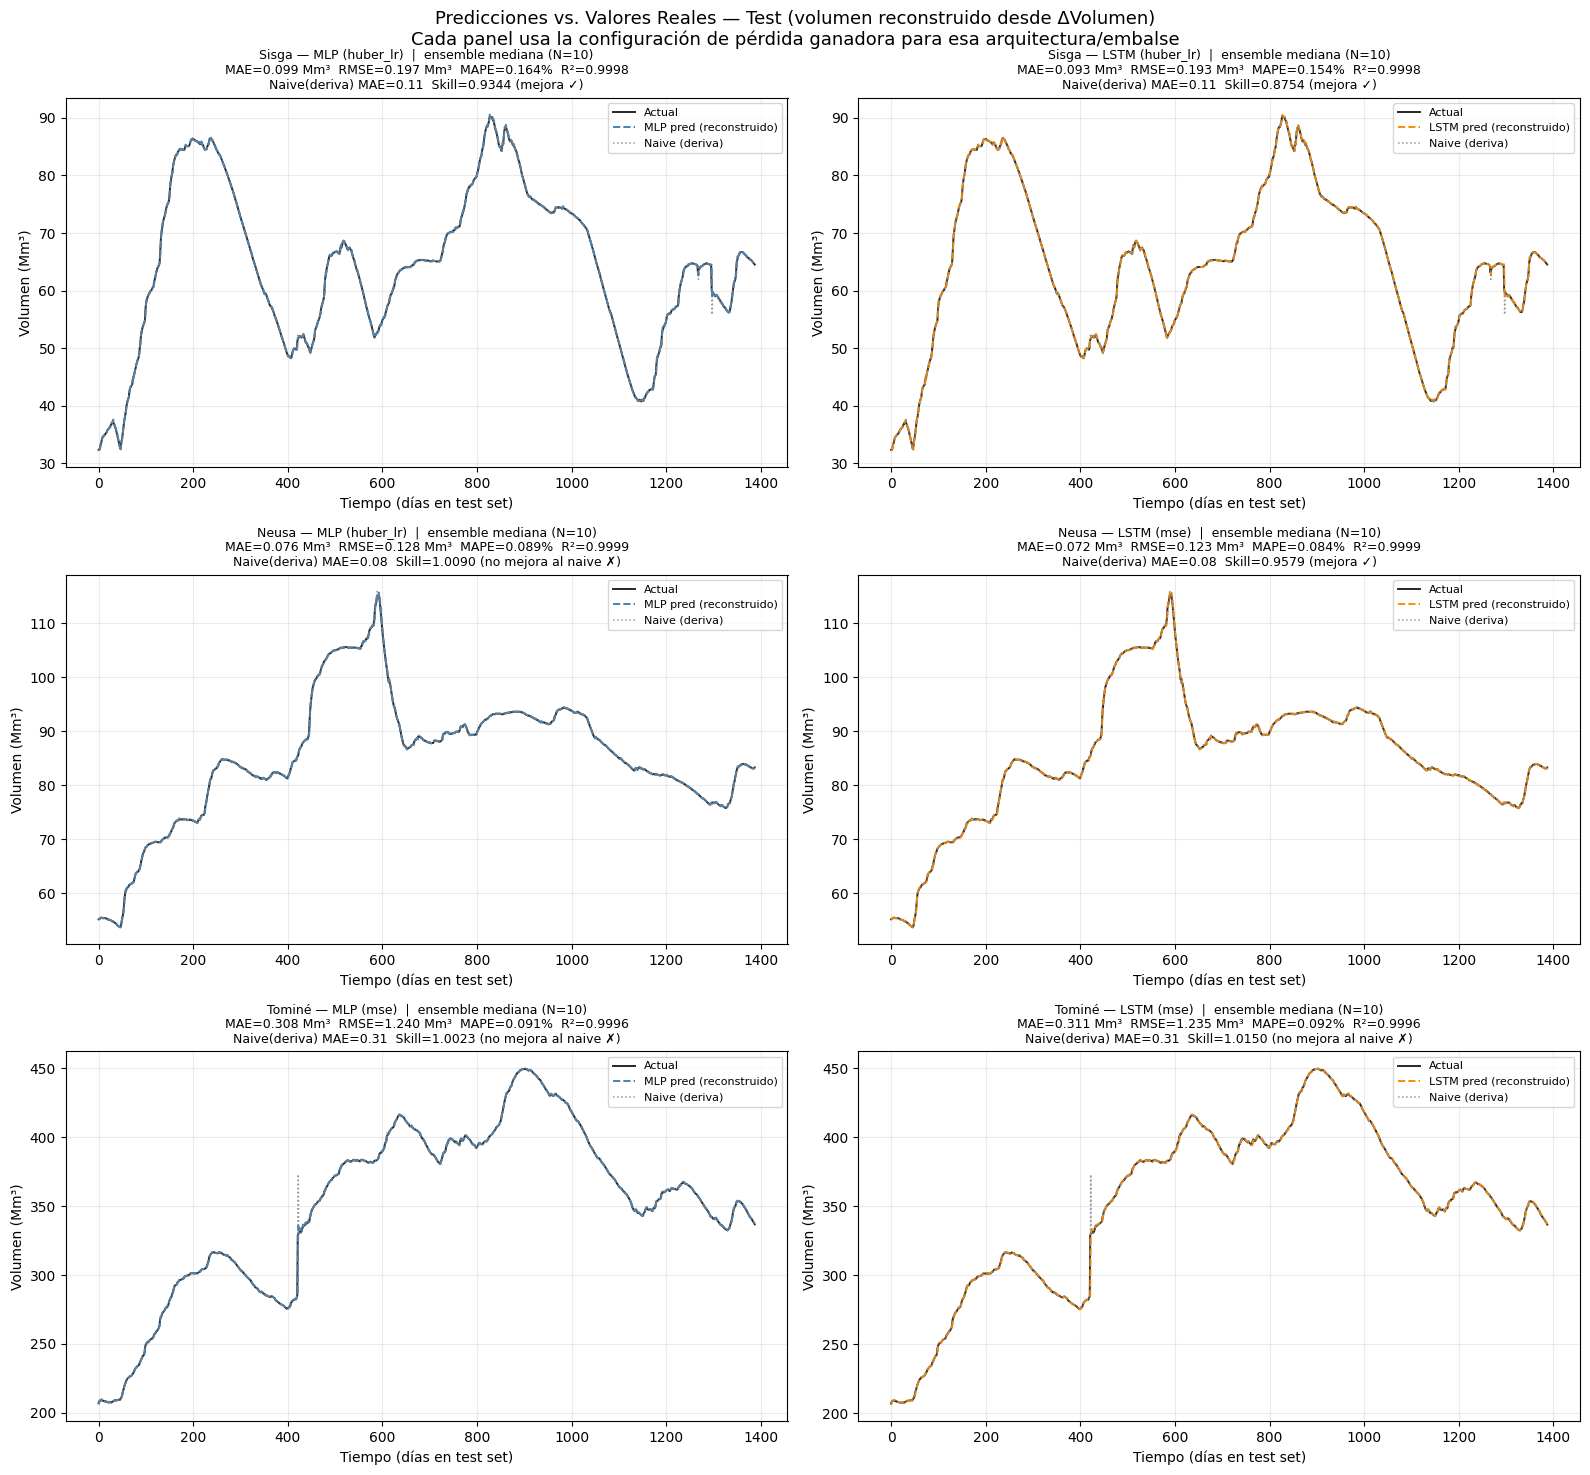

Figura guardada -> Figure_Predicciones_Test.pdf


In [ ]:
# Predicciones vs. valores reales — Test (volumen reconstruido)

fig, axes = plt.subplots(n_embalses, 2, figsize=(16, 5 * n_embalses))
axes = np.atleast_2d(axes)

for fila, embalse in enumerate(dfs_merged.keys()):
    for col, arq in enumerate(['MLP', 'LSTM']):
        info   = corridas_finales[embalse][arq]
        config = seleccion[embalse][arq]['config_ganadora']
        y_r    = info['y_real'].flatten()
        y_p    = info['pred'].flatten()
        y_n    = info['pred_naive'].flatten()
        skill  = info['mae'] / info['mae_naive']
        color  = 'steelblue' if arq == 'MLP' else 'darkorange'

        ax = axes[fila, col]
        ax.plot(y_r, label='Actual',           color='black',  linewidth=1.4, alpha=0.85)
        ax.plot(y_p, label=f'{arq} pred (reconstruido)',
                            color=color, linestyle='--', linewidth=1.4)
        ax.plot(y_n, label='Naive (deriva)',   color='gray',   linestyle=':', linewidth=1.1, alpha=0.8)

        ax.set_title(
            f'{embalse} — {arq} ({config})  |  {info["seed"]}\n'
            f'MAE={info["mae"]:.3f} Mm³  RMSE={info["rmse"]:.3f} Mm³  '
            f'MAPE={info["mape"]:.3f}%  R²={info["r2"]:.4f}\n'
            f'Naive(deriva) MAE={info["mae_naive"]:.2f}  Skill={skill:.4f} '
            f'({"mejora ✓" if skill < 1 else "no mejora al naive ✗"})',
            fontsize=9
        )
        ax.set_xlabel('Tiempo (días en test set)')
        ax.set_ylabel('Volumen (Mm³)')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.25)

plt.suptitle(
    'Predicciones vs. Valores Reales — Test (volumen reconstruido desde ΔVolumen)\n'
    'Cada panel usa la configuración de pérdida ganadora para esa arquitectura/embalse',
    fontsize=13
)
plt.tight_layout()
plt.savefig(f'{RUTA_FIGURAS}/Figure_Predicciones_Test.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()
print("Figura guardada -> Figure_Predicciones_Test.pdf")

### Celda 31 — Mejor modelo por embalse (figura combinada)

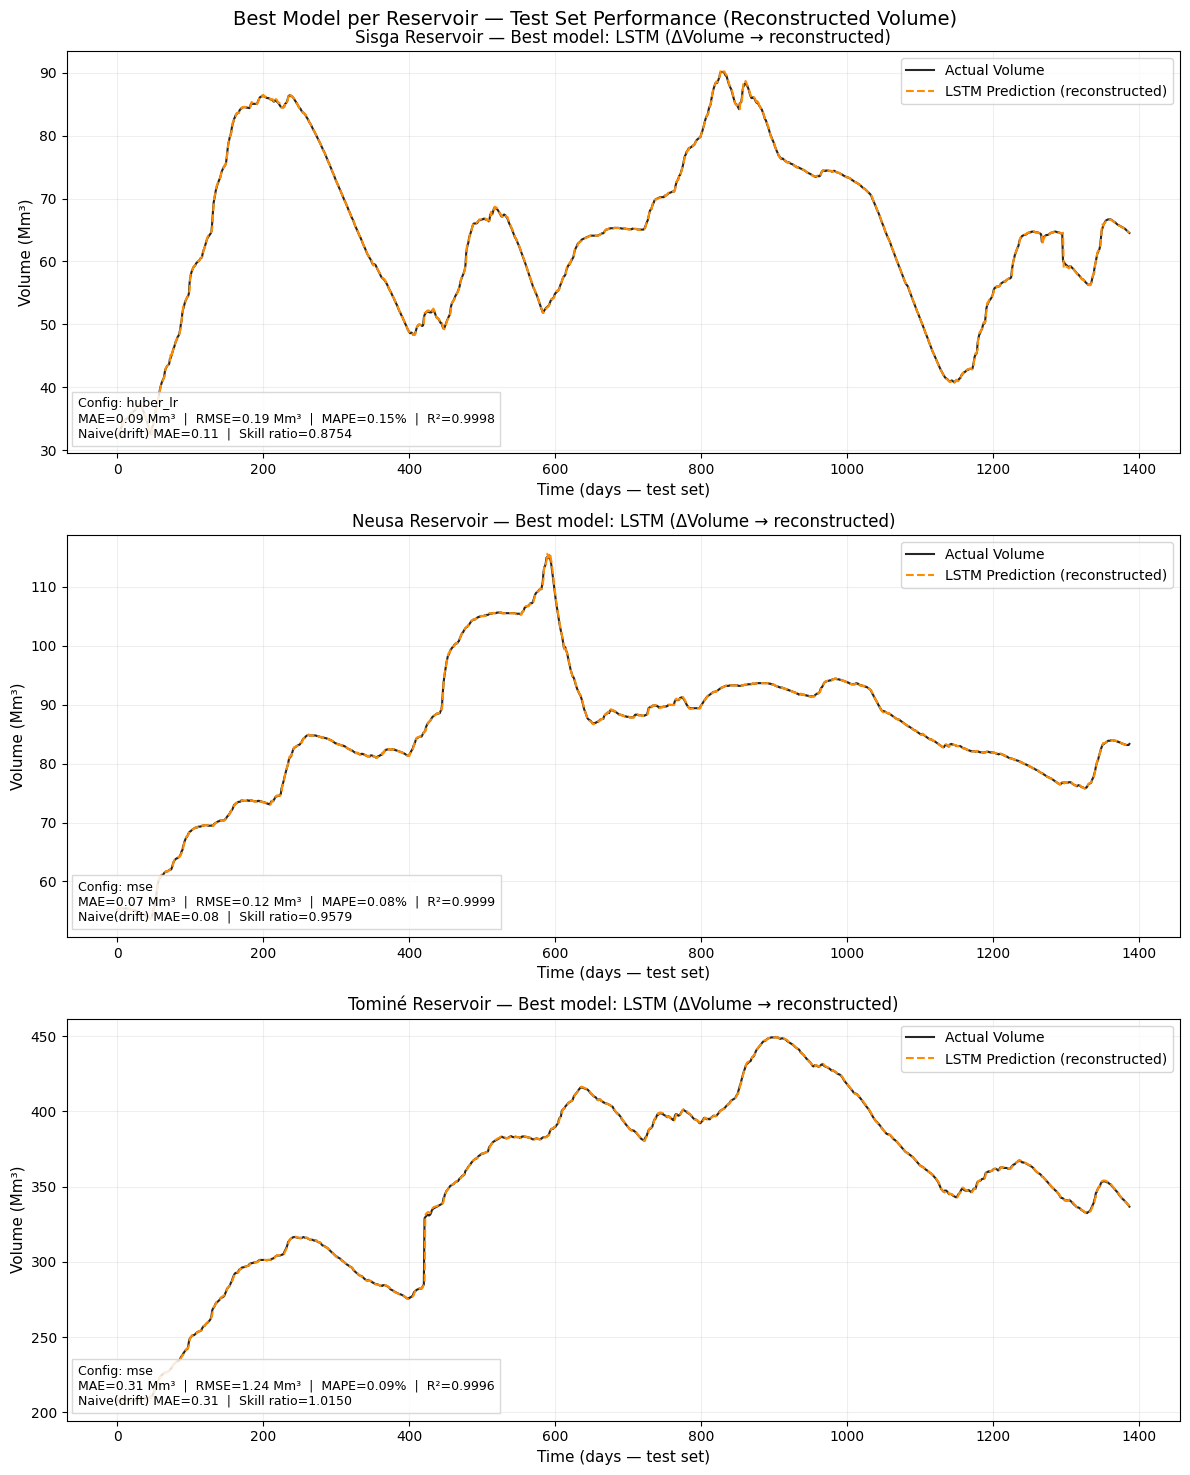

Figura guardada -> Figure_BestModel_Combined.pdf


In [ ]:
# Figura combinada: mejor modelo por embalse

fig, axes = plt.subplots(n_embalses, 1, figsize=(12, 5 * n_embalses))
axes = np.atleast_1d(axes)

for ax, embalse in zip(axes, dfs_merged.keys()):
    ganador = mejor_por_embalse[embalse]
    info    = corridas_finales[embalse][ganador]
    config  = seleccion[embalse][ganador]['config_ganadora']
    y_r     = info['y_real'].flatten()
    y_p     = info['pred'].flatten()
    color   = 'steelblue' if ganador == 'MLP' else 'darkorange'
    skill   = info['mae'] / info['mae_naive']

    ax.plot(y_r, label='Actual Volume',                  color='black', linewidth=1.5, alpha=0.85)
    ax.plot(y_p, label=f'{ganador} Prediction (reconstructed)',
                  color=color, linestyle='--', linewidth=1.5)

    txt = (f"Config: {config}\n"
           f"MAE={info['mae']:.2f} Mm³  |  RMSE={info['rmse']:.2f} Mm³  |  "
           f"MAPE={info['mape']:.2f}%  |  R²={info['r2']:.4f}\n"
           f"Naive(drift) MAE={info['mae_naive']:.2f}  |  Skill ratio={skill:.4f}")
    ax.text(0.01, 0.04, txt, transform=ax.transAxes, fontsize=9,
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray'))

    ax.set_title(f'{embalse} Reservoir — Best model: {ganador} (ΔVolume → reconstructed)', fontsize=12)
    ax.set_xlabel('Time (days — test set)', fontsize=11)
    ax.set_ylabel('Volume (Mm³)', fontsize=11)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(alpha=0.2)

plt.suptitle('Best Model per Reservoir — Test Set Performance (Reconstructed Volume)', fontsize=14)
plt.tight_layout()
plt.savefig(f'{RUTA_FIGURAS}/Figure_BestModel_Combined.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()
print("Figura guardada -> Figure_BestModel_Combined.pdf")

### Celda 32 — Análisis de residuales

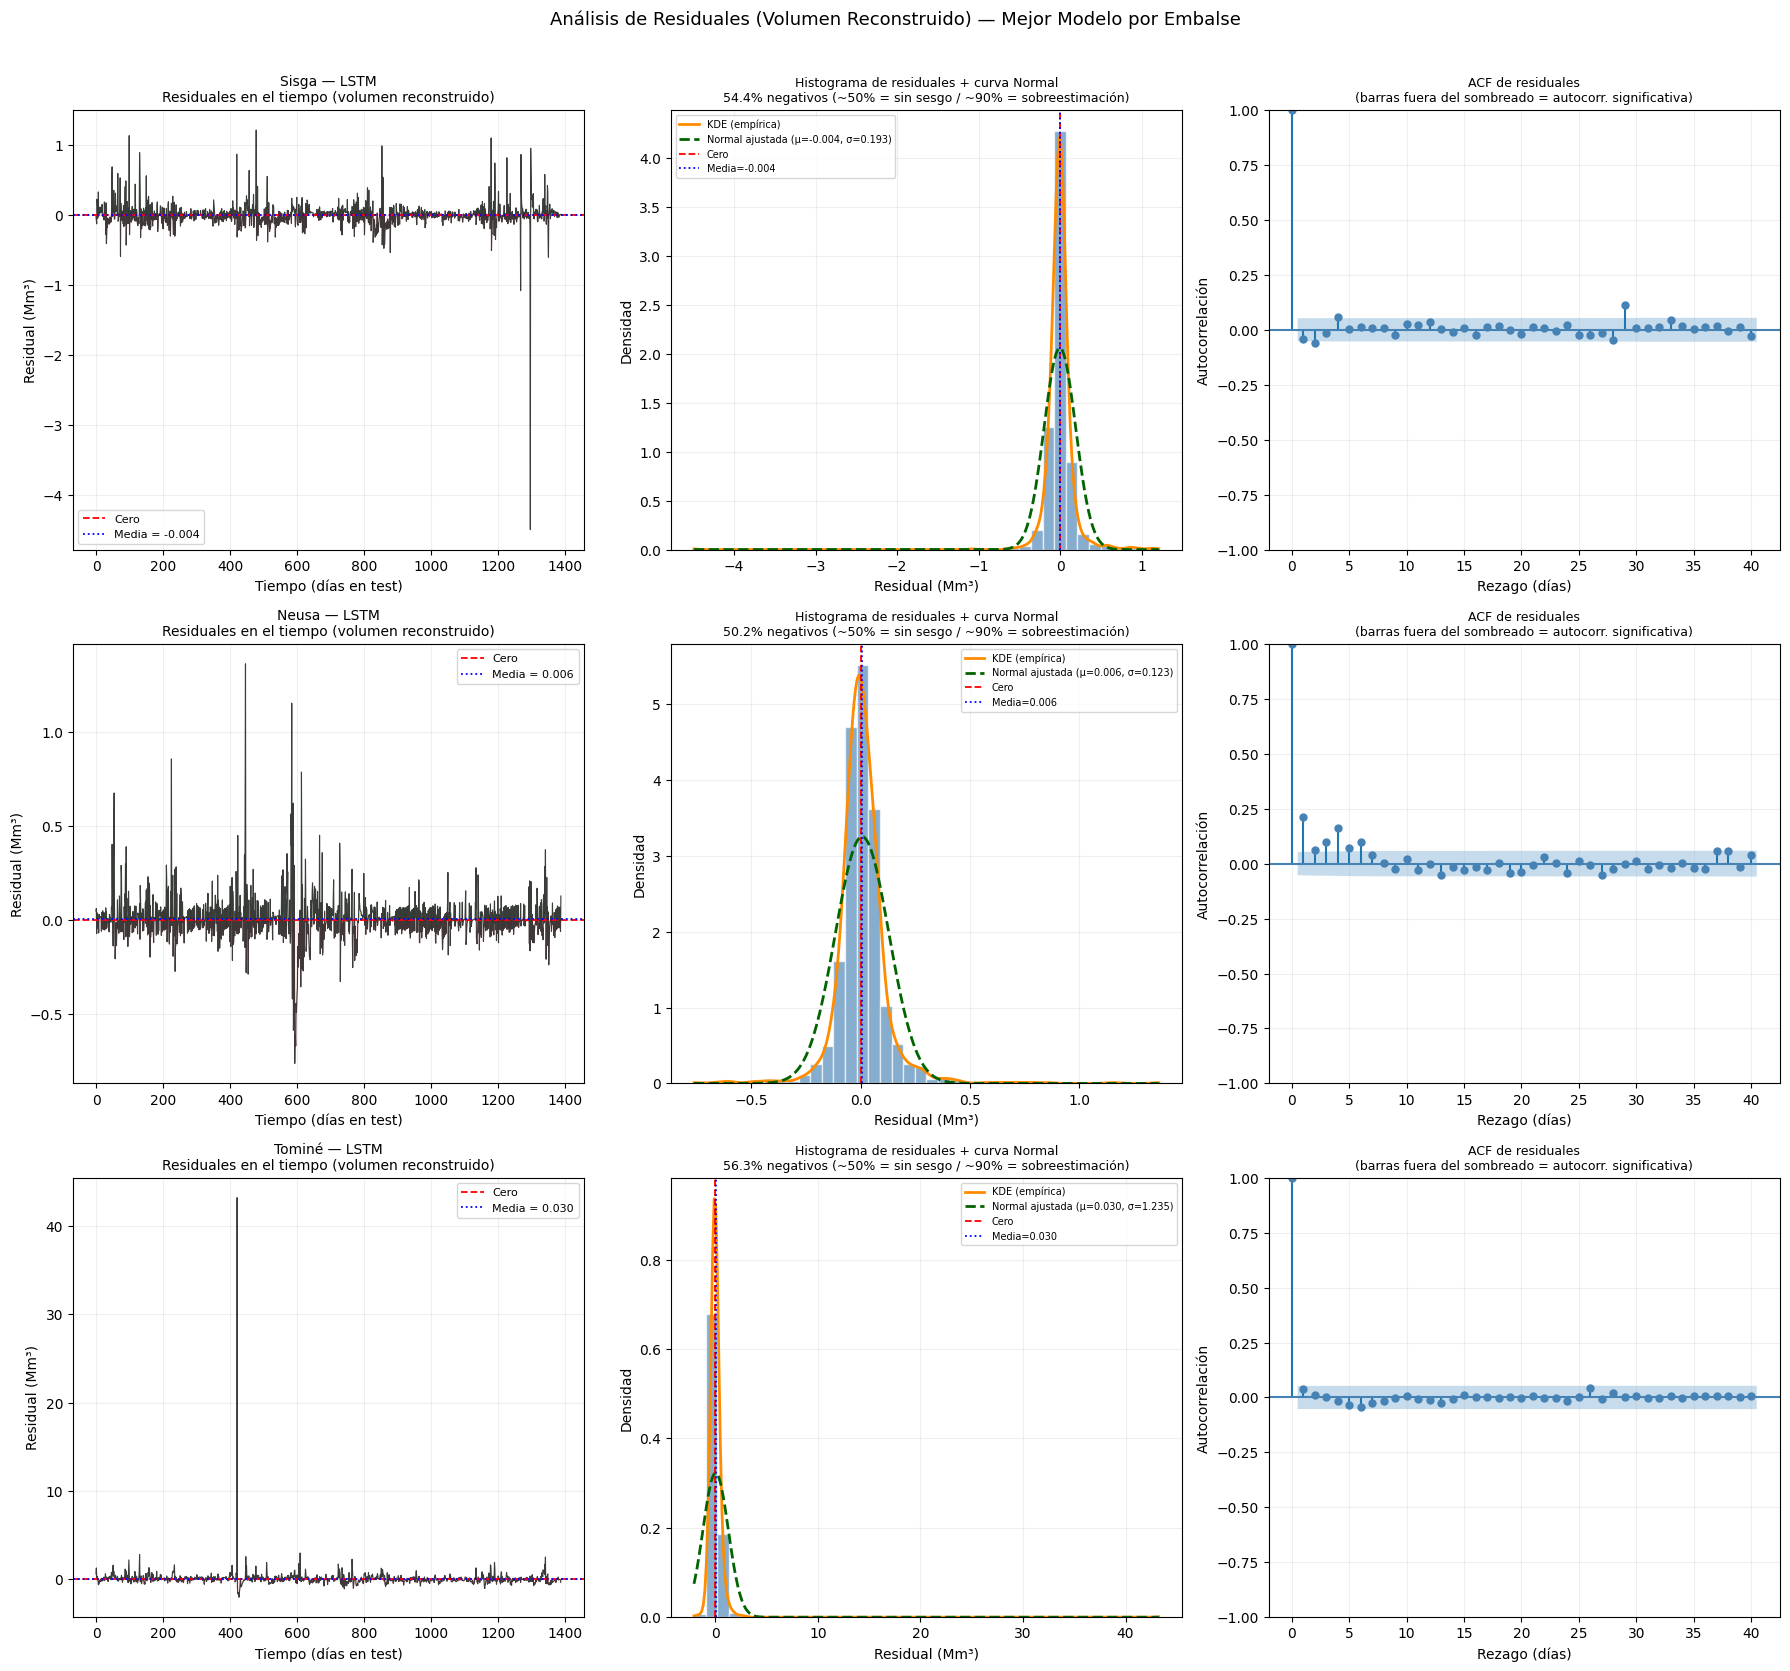

Figura guardada -> Figure_Residuals_Combined.pdf


In [ ]:
# Análisis de residuales — Volumen reconstruido

lb_resultados = {}

fig, axes = plt.subplots(n_embalses, 3, figsize=(18, 5.5 * n_embalses))
axes = np.atleast_2d(axes)

for fila, embalse in enumerate(dfs_merged.keys()):
    ganador    = mejor_por_embalse[embalse]
    info       = corridas_finales[embalse][ganador]
    residuales = info['residuales']
    n_res      = len(residuales)
    media_res  = float(np.mean(residuales))
    std_res    = float(np.std(residuales))
    pct_neg    = float(np.mean(residuales < 0) * 100)

    # Columna 0 — Residuales en el tiempo
    ax = axes[fila, 0]
    ax.plot(residuales, color='black', linewidth=0.8, alpha=0.75)
    ax.axhline(0,         color='red',  linestyle='--', linewidth=1.3, label='Cero')
    ax.axhline(media_res, color='blue', linestyle=':',  linewidth=1.3, label=f'Media = {media_res:.3f}')
    ax.fill_between(range(n_res), residuales, 0, where=(residuales < 0), color='red',   alpha=0.08)
    ax.fill_between(range(n_res), residuales, 0, where=(residuales > 0), color='green', alpha=0.08)
    ax.set_title(f'{embalse} — {ganador}\nResiduales en el tiempo (volumen reconstruido)', fontsize=10)
    ax.set_xlabel('Tiempo (días en test)'); ax.set_ylabel('Residual (Mm³)')
    ax.legend(fontsize=8); ax.grid(alpha=0.2)

    # Columna 1 — Histograma + KDE + Normal ajustada
    ax = axes[fila, 1]
    ax.hist(residuales, bins=40, color='steelblue', alpha=0.65, edgecolor='white', density=True)
    eje_x = np.linspace(residuales.min(), residuales.max(), 300)
    kde   = gaussian_kde(residuales)
    ax.plot(eje_x, kde(eje_x), color='darkorange', linewidth=2.0, label='KDE (empírica)')
    ax.plot(eje_x, norm.pdf(eje_x, loc=media_res, scale=std_res),
            color='darkgreen', linewidth=2.0, linestyle='--',
            label=f'Normal ajustada (μ={media_res:.3f}, σ={std_res:.3f})')
    ax.axvline(0,         color='red',  linestyle='--', linewidth=1.3, label='Cero')
    ax.axvline(media_res, color='blue', linestyle=':',  linewidth=1.3, label=f'Media={media_res:.3f}')
    ax.set_title(f'Histograma de residuales + curva Normal\n{pct_neg:.1f}% negativos '
                 f'(~50% = sin sesgo / ~90% = sobreestimación)', fontsize=9)
    ax.set_xlabel('Residual (Mm³)'); ax.set_ylabel('Densidad')
    ax.legend(fontsize=7); ax.grid(alpha=0.2)

    # Columna 2 — ACF de residuales
    ax = axes[fila, 2]
    plot_acf(residuales, lags=min(40, n_res // 4), ax=ax, color='steelblue', title='')
    ax.set_title('ACF de residuales\n(barras fuera del sombreado = autocorr. significativa)', fontsize=9)
    ax.set_xlabel('Rezago (días)'); ax.set_ylabel('Autocorrelación'); ax.grid(alpha=0.2)

    lb = acorr_ljungbox(residuales, lags=[10, 20, 30], return_df=True)
    lb_resultados[embalse] = {
        'modelo': ganador, 'config': seleccion[embalse][ganador]['config_ganadora'],
        'info': info, 'media': media_res, 'std': std_res, 'pct_neg': pct_neg, 'lb': lb,
    }

plt.suptitle('Análisis de Residuales (Volumen Reconstruido) — Mejor Modelo por Embalse',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{RUTA_FIGURAS}/Figure_Residuals_Combined.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()
print("Figura guardada -> Figure_Residuals_Combined.pdf")

### Celda 33 — Resultados numéricos de residuales y Ljung-Box

In [ ]:
# Resultados numéricos de residuales y test de Ljung-Box

print("\n" + "=" * 70)
print("RESULTADOS NUMÉRICOS: RESIDUALES (VOLUMEN RECONSTRUIDO) Y TEST DE LJUNG-BOX")
print("=" * 70)

for embalse, res in lb_resultados.items():
    info  = res['info']
    skill = info['mae'] / info['mae_naive']
    print(f"\n{'─'*65}")
    print(f"Embalse : {embalse}   |   Modelo : {res['modelo']}   |   Config : {res['config']}")
    print(f"{'─'*65}")
    print(f"  MAE                  : {info['mae']:.4f} Mm³")
    print(f"  RMSE                 : {info['rmse']:.4f} Mm³")
    print(f"  MAPE                 : {info['mape']:.4f} %")
    print(f"  R²                   : {info['r2']:.6f}")
    print(f"  MAE naive (deriva)   : {info['mae_naive']:.4f} Mm³")
    print(f"  Skill ratio          : {skill:.4f}  "
          f"({'modelo mejora al naive ✓' if skill < 1 else 'modelo NO mejora al naive ✗'})")

    bias_ok = abs(res['media']) < info['mae'] * 0.05
    pct_ok  = abs(res['pct_neg'] - 50) < 10
    print(f"\n  Media residuales     : {res['media']:.4f} Mm³  "
          f"({'≈ 0, sin sesgo ✓' if bias_ok else 'SESGO DETECTADO ✗'})")
    print(f"  Desv. estándar       : {res['std']:.4f} Mm³")
    print(f"  % residuales < 0     : {res['pct_neg']:.1f}%  "
          f"({'≈ 50%, sin sesgo direccional ✓' if pct_ok else 'SESGO DIRECCIONAL ✗ (esperado ~50%)'})")

    print(f"\n  Ljung-Box — residuales (volumen reconstruido):")
    for idx, row in res['lb'].iterrows():
        marca = ("<- Rechaza H0 (autocorr. significativa)  ✗"
                 if row['lb_pvalue'] < 0.05 else "<- No rechaza H0  ✓")
        print(f"    Lag {int(idx):2d}:  Q={row['lb_stat']:7.3f}  p={row['lb_pvalue']:.4f}  {marca}")

print("\n" + "=" * 70)
print("FIN DEL ANÁLISIS — (bivariado: ΔVolumen + Precipitación)")
print("=" * 70)


RESULTADOS NUMÉRICOS: RESIDUALES (VOLUMEN RECONSTRUIDO) Y TEST DE LJUNG-BOX

─────────────────────────────────────────────────────────────────
Embalse : Sisga   |   Modelo : LSTM   |   Config : huber_lr
─────────────────────────────────────────────────────────────────
  MAE                  : 0.0929 Mm³
  RMSE                 : 0.1935 Mm³
  MAPE                 : 0.1535 %
  R²                   : 0.999794
  MAE naive (deriva)   : 0.1061 Mm³
  Skill ratio          : 0.8754  (modelo mejora al naive ✓)

  Media residuales     : -0.0044 Mm³  (≈ 0, sin sesgo ✓)
  Desv. estándar       : 0.1934 Mm³
  % residuales < 0     : 54.4%  (≈ 50%, sin sesgo direccional ✓)

  Ljung-Box — residuales (volumen reconstruido):
    Lag 10:  Q= 15.146  p=0.1268  <- No rechaza H0  ✓
    Lag 20:  Q= 19.788  p=0.4713  <- No rechaza H0  ✓
    Lag 30:  Q= 44.617  p=0.0419  <- Rechaza H0 (autocorr. significativa)  ✗

─────────────────────────────────────────────────────────────────
Embalse : Neusa   |   Modelo : LS

### Celda 34 - Pronóstico Iterativo

In [ ]:
# Pronóstico multi-step iterativo (30 días)

#   - forecast_iterativo_individual usa DOS ventanas: ΔVol + Precip
#   - La ventana de Precip se actualiza en cada paso con el valor real
#     de precipitación disponible en X_test (ya viene como Precip(t-1),
#     sin fuga de información, igual que en el entrenamiento)
#     Punto de arranque = índice de máxima variación conjunta en test
#     Naive = persistencia plana (vol. del punto de arranque)
#     Ensemble por mediana de las N semillas
#      Figura con grilla embalse × arquitectura

# Buscar punto de arranque óptimo (máxima variación conjunta)

ref_embalses = {
    embalse: seleccion[embalse]['MLP']['corridas'][0]['test']
    for embalse in dfs_merged.keys()
}

horizonte  = 30
n_test     = len(list(ref_embalses.values())[0]['y_real'])
variaciones = []

for idx in range(n_test - horizonte):
    var_total = 0
    for embalse, ref in ref_embalses.items():
        y = ref['y_real'].flatten()[idx:idx + horizonte]
        v = ref['vol_t_minus_1'][idx]
        var_total += np.std(y - v)
    variaciones.append((idx, var_total))

top5 = sorted(variaciones, key=lambda x: x[1], reverse=True)[:5]
print("Top 5 puntos de arranque por variación conjunta:")
for idx, var in top5:
    print(f"  idx={idx:4d}  variación conjunta={var:.3f}")
    for embalse, ref in ref_embalses.items():
        y = ref['y_real'].flatten()[idx:idx + horizonte]
        v = ref['vol_t_minus_1'][idx]
        print(f"    {embalse}: arranque={v:.2f}  día30={y[-1]:.2f}  "
              f"Δtotal={y[-1]-v:.2f}  "
              f"MAE_naive={mean_absolute_error(y, np.full(30, v)):.3f}")

IDX_ARRANQUE       = top5[0][0]   # índice de mayor variación conjunta
HORIZONTE_FORECAST = 30
print(f"\nÍndice de arranque seleccionado automáticamente: idx={IDX_ARRANQUE}")

Top 5 puntos de arranque por variación conjunta:
  idx= 405  variación conjunta=28.180
    Sisga: arranque=48.59  día30=52.12  Δtotal=3.53  MAE_naive=2.092
    Neusa: arranque=82.36  día30=88.12  Δtotal=5.76  MAE_naive=3.171
    Tominé: arranque=277.27  día30=335.65  Δtotal=58.38  MAE_naive=27.890
  idx= 406  variación conjunta=28.162
    Sisga: arranque=48.40  día30=51.83  Δtotal=3.43  MAE_naive=2.356
    Neusa: arranque=82.63  día30=88.21  Δtotal=5.58  MAE_naive=3.091
    Tominé: arranque=277.74  día30=335.92  Δtotal=58.18  MAE_naive=29.357
  idx= 407  variación conjunta=28.046
    Sisga: arranque=48.30  día30=51.48  Δtotal=3.18  MAE_naive=2.544
    Neusa: arranque=83.08  día30=88.30  Δtotal=5.23  MAE_naive=2.820
    Tominé: arranque=279.17  día30=336.19  Δtotal=57.03  MAE_naive=29.835
  idx= 404  variación conjunta=28.046
    Sisga: arranque=48.68  día30=52.27  Δtotal=3.59  MAE_naive=1.911
    Neusa: arranque=82.19  día30=88.03  Δtotal=5.84  MAE_naive=3.157
    Tominé: arranque=276.

#### Celda 35 - Función de pronóstico

In [ ]:
# Función de pronóstico individual (una semilla)

def forecast_iterativo_individual(r: dict, idx: int,
                                       horizonte: int = 30) -> np.ndarray:
    """
    Pronóstico multi-step iterativo para UNA semilla (bivariado).

    En cada paso h:
      1. Predice ΔVol_pred(t+h) con la ventana actual de [ΔVol, Precip].
      2. Reconstruye Vol(t+h) = Vol(t+h-1) + ΔVol_pred(t+h).
      3. Actualiza la ventana de ΔVol con ΔVol_pred (valor predicho).
      4. Actualiza la ventana de Precip con el valor real que ya estaba
         en X_test[idx+h] — canal 1 si LSTM (formato_3d), mitad derecha
         si MLP. Este valor es Precip(t+h-1) respecto al target, es decir,
         el mismo desfase que se usó en el entrenamiento → sin fuga.
    """
    model       = r['model']
    scaler_vol  = r['scaler_vol']
    scaler_prec = r['scaler_prec']
    formato_3d  = r['formato_3d']
    ventana     = r['ventana']

    # Ventana inicial en espacio escalado
    ventana_actual = r['X_test'][idx].copy()   # (ventana, 2) si 3d, (ventana*2,) si MLP

    vol_actual = float(r['test']['vol_t_minus_1'][idx])
    preds_vol  = []

    for h in range(horizonte):
        # Predecir
        if formato_3d:
            entrada = ventana_actual.reshape(1, ventana, 2)
        else:
            entrada = ventana_actual.reshape(1, ventana * 2)

        delta_scaled = model.predict(entrada, verbose=0)              # (1,1) escalado
        delta        = float(scaler_vol.inverse_transform(delta_scaled)[0, 0])
        vol_actual  += delta
        preds_vol.append(vol_actual)

        # Valor escalado del ΔVol predicho (para actualizar ventana)
        nuevo_dvol = float(delta_scaled[0, 0])

        # Valor escalado de Precip del SIGUIENTE paso desde X_test
        # (si está disponible; si no, repite el último valor de Precip)
        idx_siguiente = idx + h + 1
        if idx_siguiente < len(r['X_test']):
            if formato_3d:
                nuevo_prec = float(r['X_test'][idx_siguiente][-1, 1])
            else:
                nuevo_prec = float(r['X_test'][idx_siguiente][ventana - 1 + ventana])
                # X_test MLP: [dv_0..dv_{v-1}, pp_0..pp_{v-1}]
                # el último Precip de la ventana siguiente está en posición 2*ventana-1
                nuevo_prec = float(r['X_test'][idx_siguiente][2 * ventana - 1])
        else:
            # Fuera del test: repetir último valor de Precip de la ventana
            if formato_3d:
                nuevo_prec = float(ventana_actual[-1, 1])
            else:
                nuevo_prec = float(ventana_actual[2 * ventana - 1])

        # Desplazar ventana un paso
        if formato_3d:
            ventana_actual = np.roll(ventana_actual, -1, axis=0)
            ventana_actual[-1, 0] = nuevo_dvol
            ventana_actual[-1, 1] = nuevo_prec
        else:
            # Primeros `ventana` valores = ΔVol; segundos `ventana` = Precip
            ventana_actual = np.roll(ventana_actual, -1)
            ventana_actual[ventana - 1]     = nuevo_dvol
            ventana_actual[2 * ventana - 1] = nuevo_prec

    return np.array(preds_vol)

# Función ensemble (mediana sobre N semillas)

def forecast_iterativo_ensemble(corridas: list, idx: int,
                                     horizonte: int = 30,
                                     metodo: str = 'mediana') -> dict:
    trayectorias = np.stack([
        forecast_iterativo_individual(r, idx, horizonte) for r in corridas
    ])

    pred_vol_ens = (np.median(trayectorias, axis=0) if metodo == 'mediana'
                    else trayectorias.mean(axis=0))

    ref          = corridas[0]['test']
    y_real       = ref['y_real'].flatten()[idx:idx + horizonte]
    vol_arranque = float(ref['vol_t_minus_1'][idx])
    naive        = np.full(horizonte, vol_arranque)   # persistencia plana

    mae_modelo      = mean_absolute_error(y_real, pred_vol_ens)
    mae_naive_plano = mean_absolute_error(y_real, naive)
    skill = mae_modelo / mae_naive_plano if mae_naive_plano > 0 else np.nan

    return {
        'horizonte': horizonte, 'n_semillas': len(corridas),
        'pred_vol':             pred_vol_ens,
        'trayectorias':         trayectorias,
        'y_real_horizonte':     y_real,
        'pred_naive_horizonte': naive,
        'vol_arranque':         vol_arranque,
        'mae':                  mae_modelo,
        'mae_naive_plano':      mae_naive_plano,
        'skill':                skill,
    }

#### Celda 36 - Ejecución del Pronóstico

In [ ]:
# Ejecución

print(f"\nPRONÓSTICO MULTI-STEP ITERATIVO (30 días) — idx={IDX_ARRANQUE}, "
      f"máxima variación conjunta")
print("=" * 70)

forecasts = {}
for embalse in dfs_merged.keys():
    forecasts[embalse] = {}
    for arq in ['MLP', 'LSTM']:
        corridas = seleccion[embalse][arq]['corridas']
        fc = forecast_iterativo_ensemble(
            corridas, idx=IDX_ARRANQUE, horizonte=HORIZONTE_FORECAST
        )
        forecasts[embalse][arq] = fc
        print(f"{embalse:8s} — {arq:4s} (N={fc['n_semillas']}): "
              f"MAE={fc['mae']:.3f}  |  "
              f"Naive plano={fc['mae_naive_plano']:.3f}  |  "
              f"Skill={fc['skill']:.4f} "
              f"({'mejora ✓' if fc['skill'] < 1 else 'no mejora ✗'})")


PRONÓSTICO MULTI-STEP ITERATIVO (30 días) — idx=405, máxima variación conjunta
Sisga    — MLP  (N=10): MAE=6.212  |  Naive plano=2.092  |  Skill=2.9692 (no mejora ✗)
Sisga    — LSTM (N=10): MAE=0.554  |  Naive plano=2.092  |  Skill=0.2650 (mejora ✓)
Neusa    — MLP  (N=10): MAE=8.196  |  Naive plano=3.171  |  Skill=2.5844 (no mejora ✗)
Neusa    — LSTM (N=10): MAE=1.243  |  Naive plano=3.171  |  Skill=0.3921 (mejora ✓)
Tominé   — MLP  (N=10): MAE=136.036  |  Naive plano=27.890  |  Skill=4.8776 (no mejora ✗)
Tominé   — LSTM (N=10): MAE=25.071  |  Naive plano=27.890  |  Skill=0.8989 (mejora ✓)


#### Celda 36 - Figuras Pronósticos

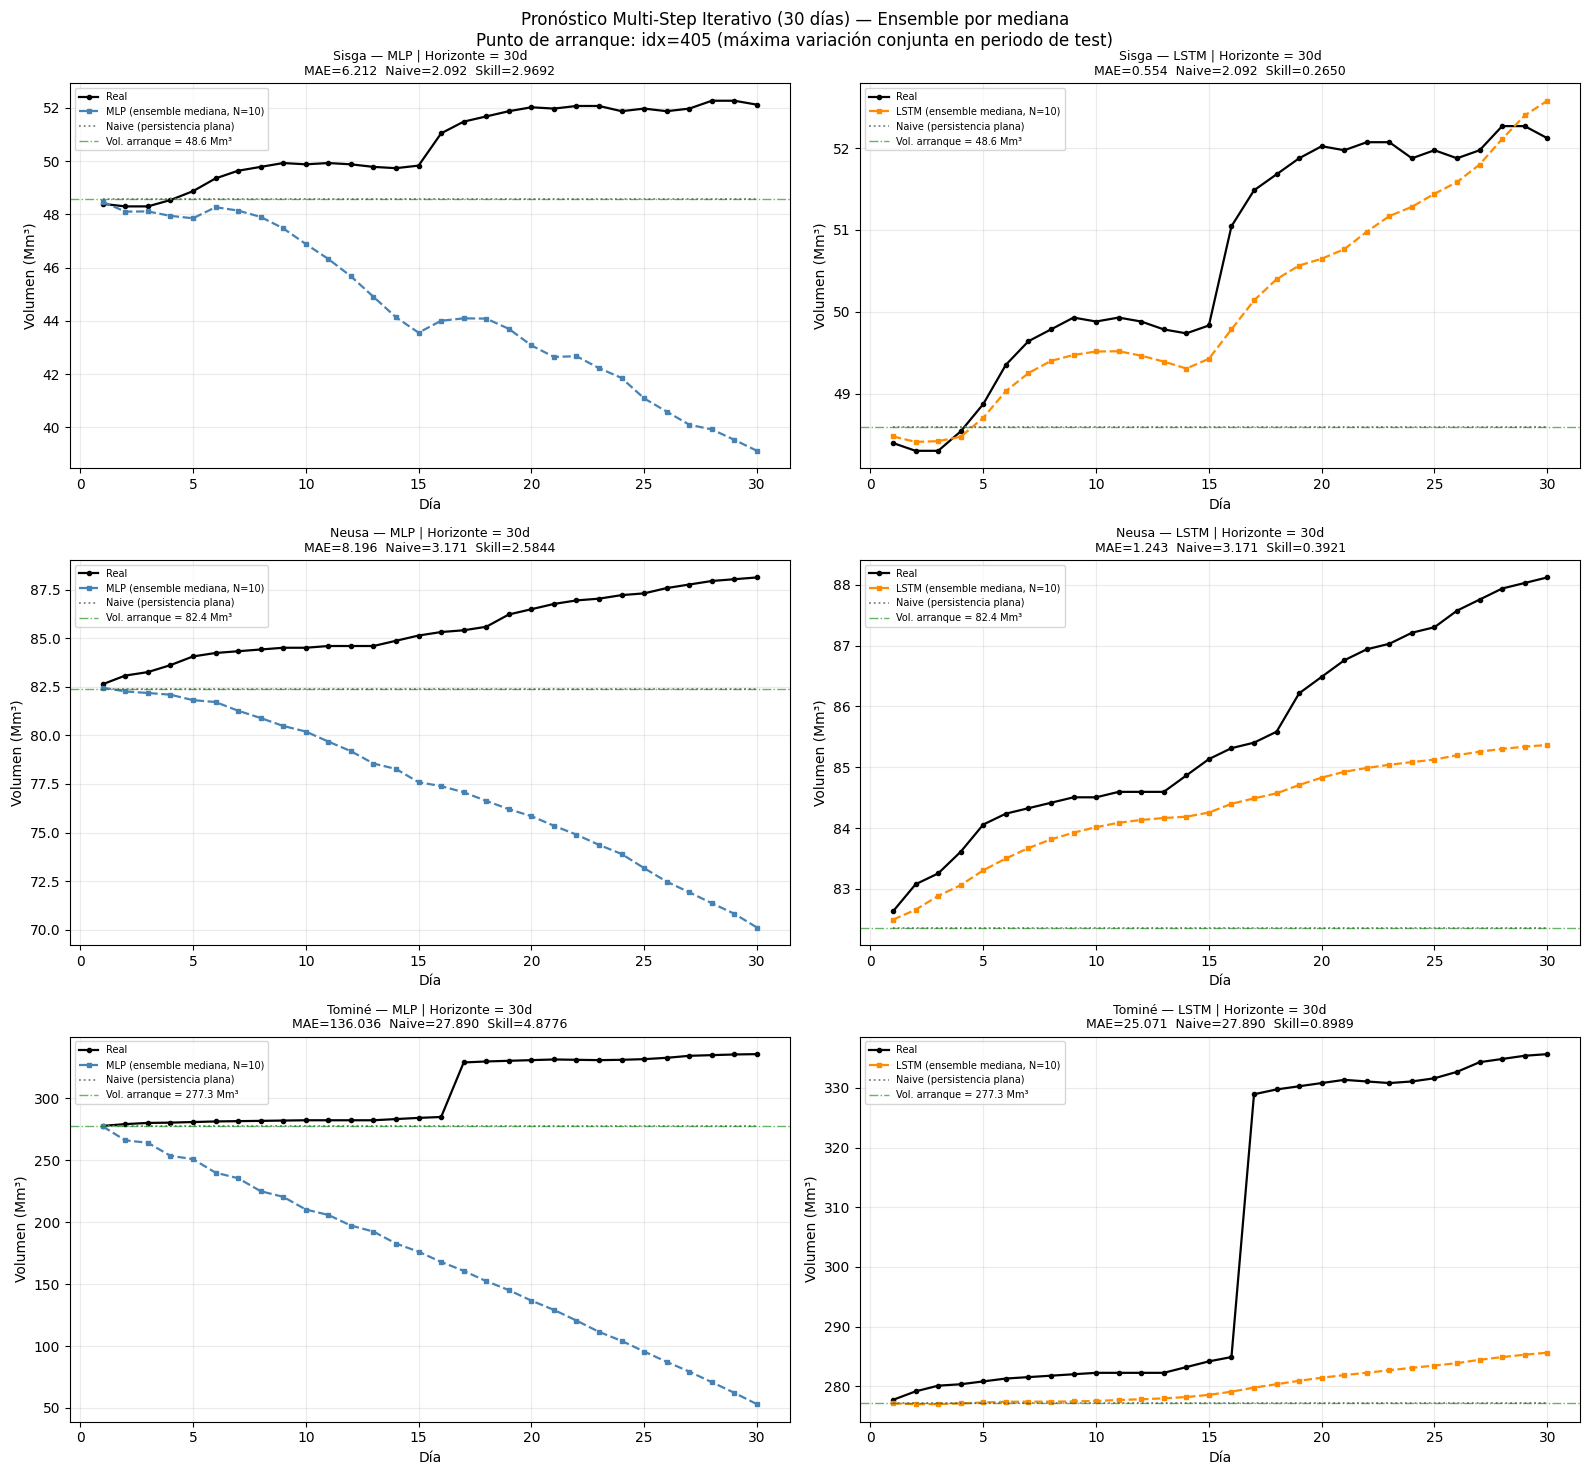


Figura guardada → Figure_Forecast_Iterativo_30d.pdf


In [ ]:
# Figura pronóstico multi-step iterativo

n_embalses = len(dfs_merged)
fig, axes = plt.subplots(n_embalses, 2, figsize=(16, 5 * n_embalses))
axes = np.atleast_2d(axes)

for fila, embalse in enumerate(dfs_merged.keys()):
    for col, arq in enumerate(['MLP', 'LSTM']):
        fc    = forecasts[embalse][arq]
        color = 'steelblue' if arq == 'MLP' else 'darkorange'
        ax    = axes[fila, col]
        dias  = np.arange(1, HORIZONTE_FORECAST + 1)

        ax.plot(dias, fc['y_real_horizonte'],
                label='Real', color='black',
                linewidth=1.6, marker='o', markersize=3)
        ax.plot(dias, fc['pred_vol'],
                label=f'{arq} (ensemble mediana, N={fc["n_semillas"]})',
                color=color, linestyle='--', linewidth=1.6, marker='s', markersize=3)
        ax.plot(dias, fc['pred_naive_horizonte'],
                label='Naive (persistencia plana)',
                color='gray', linestyle=':', linewidth=1.3)
        ax.axhline(fc['vol_arranque'], color='green', linestyle='-.',
                   linewidth=1.0, alpha=0.6,
                   label=f'Vol. arranque = {fc["vol_arranque"]:.1f} Mm³')
        ax.set_title(
            f'{embalse} — {arq} | Horizonte = 30d\n'
            f'MAE={fc["mae"]:.3f}  '
            f'Naive={fc["mae_naive_plano"]:.3f}  '
            f'Skill={fc["skill"]:.4f}',
            fontsize=9
        )
        ax.set_xlabel('Día')
        ax.set_ylabel('Volumen (Mm³)')
        ax.legend(fontsize=7)
        ax.grid(alpha=0.25)

plt.suptitle(
    f'Pronóstico Multi-Step Iterativo (30 días) — Ensemble por mediana\n'
    f'Punto de arranque: idx={IDX_ARRANQUE} (máxima variación conjunta en periodo de test)',
    fontsize=12
)
plt.tight_layout()
plt.savefig(f'{RUTA_FIGURAS}/Figure_Forecast_Iterativo_30d.pdf',
            format='pdf', bbox_inches='tight', dpi=300)
plt.show()
print("\nFigura guardada → Figure_Forecast_Iterativo_30d.pdf")

#### Celda 37 - Fechas del pronóstico

In [ ]:
# Fechas empleadas en el pronóstico anterior
for embalse in dfs_merged.keys():
    ref = seleccion[embalse]['MLP']['corridas'][0]
    n_train_val = ref['val_size'] + ref['ventana']
    idx_absoluto = n_train_val + IDX_ARRANQUE
    fecha     = dfs_merged[embalse].index[idx_absoluto]
    fecha_fin = dfs_merged[embalse].index[idx_absoluto + 29]
    print(f"{embalse}: {fecha.date()} → {fecha_fin.date()}")

Sisga: 2022-04-23 → 2022-05-22
Neusa: 2022-04-23 → 2022-05-22
Tominé: 2022-04-23 → 2022-05-22


### Guardar HTML

In [ ]:
!jupyter nbconvert --to html "/content/drive/MyDrive/Embalses/Version15.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Embalses/Version15.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 9 image(s).
[NbConvertApp] Writing 2911508 bytes to /content/drive/MyDrive/Embalses/Version15.html
